In [1]:
import json
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import statsmodels.api as sm
from odrpack import odr_fit
import random
from sklearn import metrics
from sklearn.cluster import MeanShift
import statistics
import sqlite3
import pandas
import requests
from astropy.io import fits
#import fermipy
#from fermipy.gtanalysis import GTAnalysis

In [2]:
with open('data/grb_analysis.json', 'r') as file:
    data = json.load(file)

In [3]:
r = requests.get("https://icecube.wisc.edu/~grbweb_public/GRBweb2.sqlite")
f = open('GRBweb2.sqlite', 'wb').write(r.content)

In [4]:
db = sqlite3.connect('GRBweb2.sqlite')

In [5]:
#json_read = json.dumps(data, indent=4)

In [6]:
H_naught_mpc = 67.66
H_err = 0.42
Lambda_m = 0.3103
m_err = 0.0057
Lambda_G = 0.6897
G_err = 0.0057
Lambda_k = 0.685
conversion= 3.08567758128*10**19
H_naught = H_naught_mpc/conversion

In [7]:
def f(t):
    num = np.float128((1+t))
    den = np.float128((Lambda_m*(1+t)**3)+Lambda_G)
    return num/(np.sqrt(den))

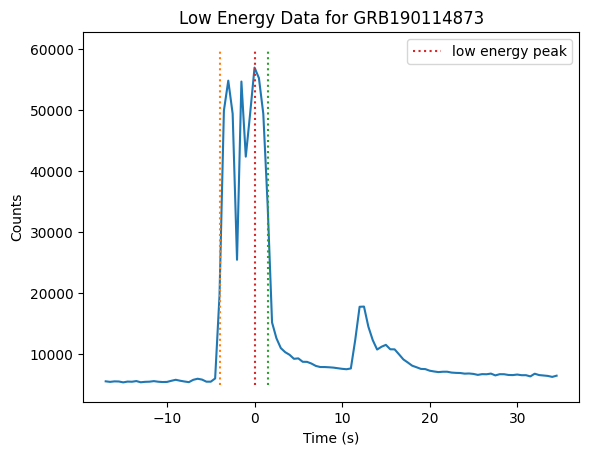

<Figure size 640x480 with 0 Axes>

In [8]:
low_lim = 250
high_lim = 680
X_prime = data["190114873"]["time_values"][low_lim:(len(data["190114873"]["time_values"])-high_lim)]
X = [[x_c[0] - data["190114873"]["low_t"]] for x_c in X_prime]
Y = data["190114873"]["time_array"][low_lim:(len(data["190114873"]["time_array"])-high_lim)]
plt.plot(X, Y)

low_half = 0
high_half = 0
for i in range(len(Y)):
    if Y[i] > 0.5*data["190114873"]["low_ct"]:
        low_half = X[i-1][0]
        high_half = low_half+data["190114873"]["half_max_t"]
        break

x = [5000,60000]
low_y= [low_half,low_half]
high_y= [high_half,high_half]
mid_y= [0,0]
plt.plot(low_y,x,linestyle = 'dotted')
plt.plot(high_y,x,linestyle = 'dotted')
plt.plot(mid_y,x,label='low energy peak',linestyle = 'dotted')

plt.title("Low Energy Data for GRB190114873")
plt.xlabel("Time (s)")
plt.ylabel("Counts")
plt.legend()
plt.show()
plt.savefig("GRB190114873.png")

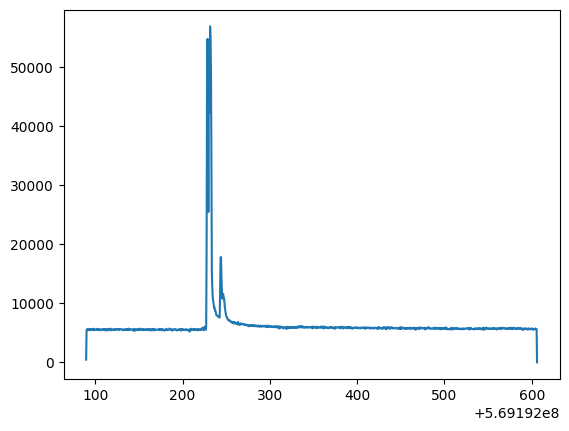

In [9]:
plt.plot(data["190114873"]["time_values"], data["190114873"]["time_array"])

In [10]:
data["190114873"]['half_max_t']

5.5

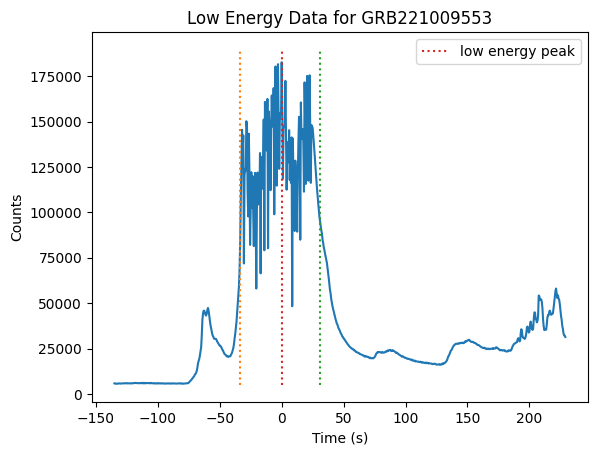

<Figure size 640x480 with 0 Axes>

In [11]:
low_lim = 500
high_lim = 1
X_prime = data["221009553"]["time_values"][low_lim:(len(data["221009553"]["time_values"])-high_lim)]
X = [[x_c[0] - data["221009553"]["low_t"]] for x_c in X_prime]
Y = data["221009553"]["time_array"][low_lim:(len(data["221009553"]["time_array"])-high_lim)]
plt.plot(X, Y)

low_half = 0
high_half = 0
for i in range(len(Y)):
    if Y[i] > 0.5*data["221009553"]["low_ct"]:
        low_half = X[i-1][0]
        high_half = low_half+data["221009553"]["half_max_t"]
        break

x = [5000,190000]
low_y= [low_half,low_half]
high_y= [high_half,high_half]
mid_y= [0,0]
plt.plot(low_y,x,linestyle = 'dotted')
plt.plot(high_y,x,linestyle = 'dotted')
plt.plot(mid_y,x,label='low energy peak',linestyle = 'dotted')

plt.title("Low Energy Data for GRB221009553")
plt.xlabel("Time (s)")
plt.ylabel("Counts")
plt.legend()
plt.show()
plt.savefig("GRB221009553.png")

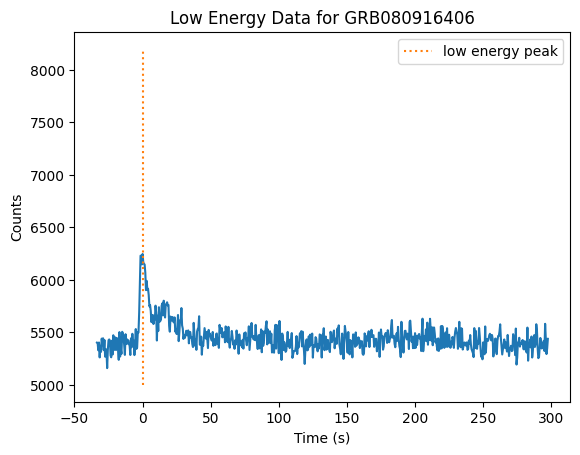

<Figure size 640x480 with 0 Axes>

In [12]:
event = "080916406"

low_lim = 1
high_lim = 1
X_prime = data[event]["time_values"][low_lim:(len(data[event]["time_values"])-high_lim)]
X = [[x_c[0] - data[event]["low_t"]] for x_c in X_prime]
Y = data[event]["time_array"][low_lim:(len(data[event]["time_array"])-high_lim)]
plt.plot(X, Y)

low_half = 0
high_half = 0
for i in range(len(Y)):
    if Y[i] > 0.5*data[event]["low_ct"]:
        low_half = X[i-1][0]
        high_half = low_half+data[event]["half_max_t"]
        break

x = [5000,8200]
#low_y= [low_half,low_half]
#high_y= [high_half,high_half]
mid_y= [0,0]
#plt.plot(low_y,x,linestyle = 'dotted')
#plt.plot(high_y,x,linestyle = 'dotted')
plt.plot(mid_y,x,label='low energy peak',linestyle = 'dotted')

plt.title("Low Energy Data for GRB" + str(event))
plt.xlabel("Time (s)")
plt.ylabel("Counts")
plt.legend()
plt.show()
plt.savefig("GBM" + str(event) + ".png")

In [13]:
data["080916406"]["half_max_t"]

7.0

In [23]:
def getLATPLOT_II(event, fov):
    time_window = 300
    e_low = 300

    grbwb_name = "GRB" + str(event)
    Sum_table = pandas.read_sql_query("SELECT * from Summary", db)
    Sum_table = Sum_table.sort_values("GRB_name_Fermi")
    indices = np.where(Sum_table == grbwb_name)
    row_indices, col_indices = indices[0], indices[1]
    index = Sum_table.iloc[row_indices].to_numpy()[0][0] - 1
    web_r = Sum_table.iloc[row_indices].ra.get(index)
    web_d = Sum_table.iloc[row_indices].decl.get(index)

    data[event]["lat_highs"]
    w = []
    for i in data[event]["lat_highs"]:
        r = float(i["RA"]) - web_r
        r = (r + 180) % 360 - 180
        d = float(i["DEC"]) - web_d
        d = (d + 180) % 360 - 180
        w.append(np.sqrt(r**2+d**2))
        
    x = [float(i["Max Time"]) - data[event]["low_t"] for i in data[event]["lat_highs"]]
    y = [float(i["Max Energy"]) for i in data[event]["lat_highs"]]
    
    X = []
    Y = []
    Z = []
    High_y = [0]
    High_x = [0]
    for i in range(len(y)):
        E = y[i]
        z = float(data[event]["redshift"])
        K_int = sp.integrate.quad(f, 0, z)[0]
        K = float(1/(H_naught))*float((E)/(1+z))*float(K_int)
        E=(K/(3*10**23))
        time_window = 120 + data[event]["half_max_t"]*5 +  E *(1+float(data[event]["redshift"]))
        #print(time_window)
        
        if x[i] < time_window and x[i] > -time_window:
            if w[i] < fov:
                if y[i] > e_low:
                    X.append(x[i])
                    Y.append(y[i])
                    Z.append([x[i],0])
                    if 0 == High_y[0]:
                        High_x[0] = x[i]
                        High_y[0] = y[i]
                    elif y[i] > 0.35*High_y[0]:
                        High_x.append(x[i])
                        High_y.append(y[i])
                        
    if High_y[0] == 0:
        return [0,0]
                    
    plt.scatter(X,Y,s=10)
    #plt.xlim(-1200, 1200)
    plt.title("High Energy Data for GRB" + event)
    plt.xlabel("Time (s)")
    plt.ylabel("Energy (MeV)")
    #plt.savefig("LAT_fig/LAT"+ event + "COEF" + str(coef) +".png")
    plt.show()
    plt.close()
    return [High_x, High_y]

In [51]:
def getLATPLOT(event):
    coef = 0.01
    fov = 60
    E = 300
    z = float(data[event]["redshift"])
    K_int = sp.integrate.quad(f, 0, z)[0]
    K = float(1/(H_naught))*float((E)/(1+z))*float(K_int)
    E=(K/(coef*10**16))

    e_low = 20
    time_window = E *(1+float(data[event]["redshift"]))
    print(time_window)

    grbwb_name = "GRB" + str(event)
    Sum_table = pandas.read_sql_query("SELECT * from Summary", db)
    Sum_table = Sum_table.sort_values("GRB_name_Fermi")
    indices = np.where(Sum_table == grbwb_name)
    row_indices, col_indices = indices[0], indices[1]
    index = Sum_table.iloc[row_indices].to_numpy()[0][0] - 1
    web_r = Sum_table.iloc[row_indices].ra.get(index)
    web_d = Sum_table.iloc[row_indices].decl.get(index)
    
    data[event]["lat_highs"]
    w = []
    for i in data[event]["lat_highs"]:
        r = float(i["RA"]) - web_r
        r = (r + 180) % 360 - 180
        d = float(i["DEC"]) - web_d
        d = (d + 180) % 360 - 180
        w.append(np.sqrt(r**2+d**2))
        
    x = [float(i["Max Time"]) - data[event]["low_t"] for i in data[event]["lat_highs"]]
    #x = [float(i["Max Time"]) - data[event]["low_t"] for i in data[event]["lat_highs"]]
    y = [float(i["Max Energy"]) for i in data[event]["lat_highs"]]
    
    X = []
    Y = []
    Z = []
    for i in range(len(y)):
        if x[i] < time_window and x[i] > -time_window:
            if w[i] < fov:
                if y[i] > e_low:
                    X.append(x[i])
                    Y.append(y[i])
                    Z.append([x[i],0])

    #plt.scatter(X,Y,s=10)

    #return "hello"
            
    print("GRB" + event + ":")   
    eps = 500 #data[event]["half_max_t"]
    try:
        ms_db = MeanShift(cluster_all=False).fit(Z)
    except:
        return ["Error 1: MS Fail"]
    labels = ms_db.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    print("Estimated number of clusters: %d" % n_clusters_)
    print("Estimated number of noise points: %d" % n_noise_)
    print("Halfmax: %d" % eps)


    print(ms_db.cluster_centers_)

    cluster_averages = []
    for j in range(len(ms_db.cluster_centers_)):
        sum_E = [0,0]
        sum_eighty_E = [0]
        sum_half_E = [0]
        for k in range(len(X)):
            if abs(X[k]-ms_db.cluster_centers_[j][0]) < (eps):
                sum_E.append(Y[k])
                if Y[k] > (0.2*Y[0]):
                    print("Adding Eighty:" + str(Y[k]))
                    sum_eighty_E.append(Y[k])
                if Y[k] > (0.5*Y[0]):
                    sum_half_E.append(Y[k])
        if len(sum_E) > 3:
            sum_E.pop(0)
            sum_E.pop(0)
        elif len(sum_E) > 2:
            sum_E.pop(0)
        if len(sum_eighty_E) > 1:
            sum_eighty_E.pop(0)
        if len(sum_half_E) > 1:
            sum_half_E.pop(0)
        sum_ave = statistics.mean(sum_E)
        sum_eighty_ave = statistics.mean(sum_eighty_E)
        sum_half_ave = statistics.mean(sum_half_E)
        cluster_averages.append([ms_db.cluster_centers_[j][0],len(sum_E),statistics.stdev(sum_E),[sum_ave,sum_eighty_ave,sum_half_ave]])
    
    print(ms_db)

    #plt.scatter()
    plt.scatter(X,Y,s=10)
    #plt.xlim(-1200, 1200)
    plt.title("High Energy Data for GRB" + event)
    plt.xlabel("Time (s)")
    plt.ylabel("Energy (MeV)")
    plt.savefig("LAT_fig/LAT"+ event + "COEF" + str(coef) +".png")
    plt.show()
    plt.close()
    return cluster_averages

In [16]:
hdul_image = fits.open("data/L26022319575973F5857911_PH00.fits")
hdul_data = hdul_image[1].data

In [17]:
#hdul_data

214002.69072623178
GRB221009553:
Estimated number of clusters: 3
Estimated number of noise points: 0
Halfmax: 500
[[ -386.85145316     0.        ]
 [ 4814.64084898     0.        ]
 [-6420.05329963     0.        ]]
Adding Eighty:99325.36
Adding Eighty:75156.18
Adding Eighty:64973.117
Adding Eighty:38901.035
MeanShift(cluster_all=False)


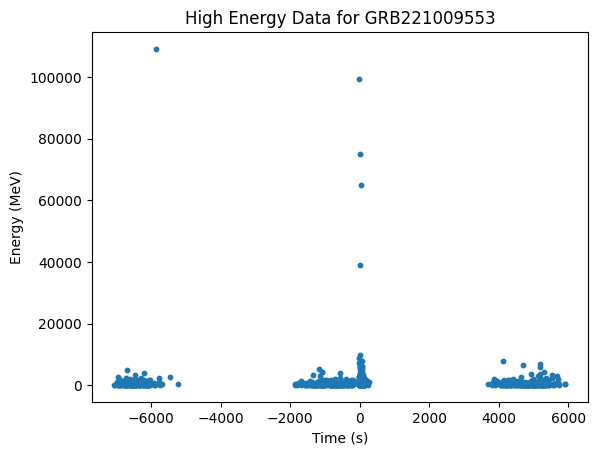

[[np.float64(-386.8514531626295),
  323,
  8105.661369123258,
  [1862.3776319349845, 69588.923, 79818.219]],
 [np.float64(4814.640848978472),
  198,
  955.953556949708,
  [599.5810177474748, 0, 0]],
 [np.float64(-6420.053299626412),
  146,
  709.0827155966637,
  [533.5624970547946, 0, 0]]]

In [52]:
getLATPLOT("221009553")

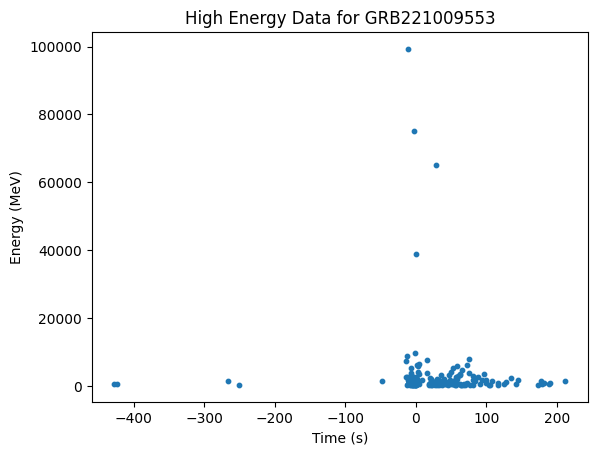

[[-10.661797642707825, -2.57060444355011, 28.34434962272644, 0.7262215614318848], [99325.36, 75156.18, 64973.117, 38901.035]]


In [24]:
print(getLATPLOT_II("221009553", 10))

1039825.8253962169
GRB080916406:
Estimated number of clusters: 3
Estimated number of noise points: 8
Halfmax: 500
[[  4621.75336521      0.        ]
 [ 25016.72670005      0.        ]
 [-15151.00818007      0.        ]]
MeanShift(cluster_all=False)


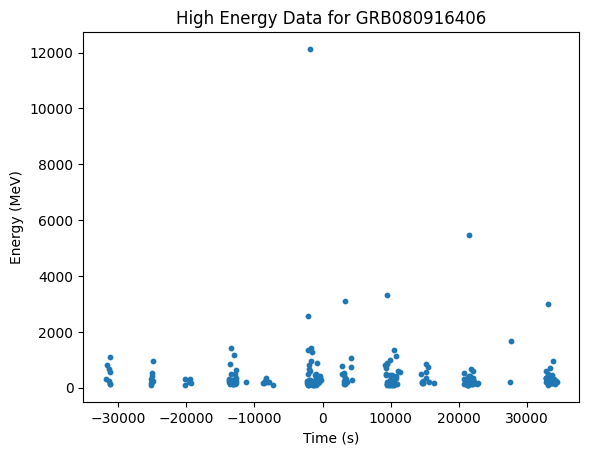

[[np.float64(4621.753365211058), 2, 324.5927504964035, [499.327635, 0, 0]],
 [np.float64(25016.72670004695), 2, 0.0, [0, 0, 0]],
 [np.float64(-15151.008180069535), 2, 0.0, [0, 0, 0]]]

In [54]:
getLATPLOT("080916406")

In [470]:
#data

In [471]:
data["080916406"]["lat_highs"][len(data["080916406"]["lat_highs"])-1]

{'Max Time': '243260841.34747288',
 'Max Energy': '100.7051',
 'RA': '327.34573',
 'DEC': '-61.38117'}

In [26]:
data["080916009"]

KeyError: '080916009'

In [27]:
getLATPLOT_II("080916406", 20)

[0, 0]

In [28]:
#getLATPLOT(list(data.items())[0][0])

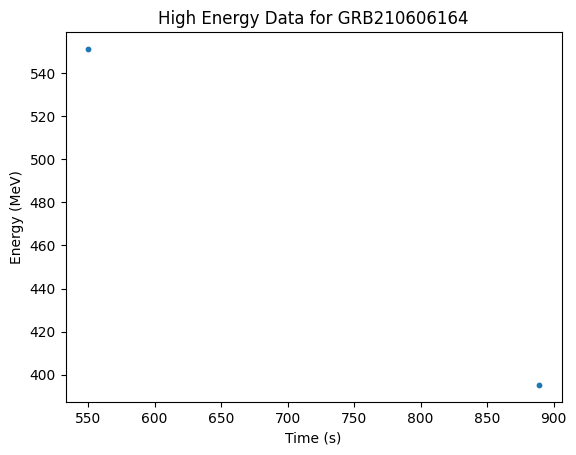

[[550.1446750164032, 889.1652220487595], [551.22235, 395.29315]]


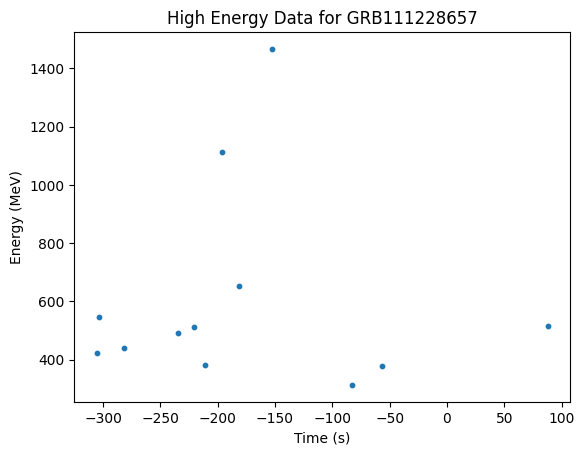

[[-152.59854567050934, -196.65603411197662, -181.32696789503098, -303.59990614652634, 88.03871881961823], [1467.227, 1114.7386, 652.8751, 548.0287, 514.26373]]


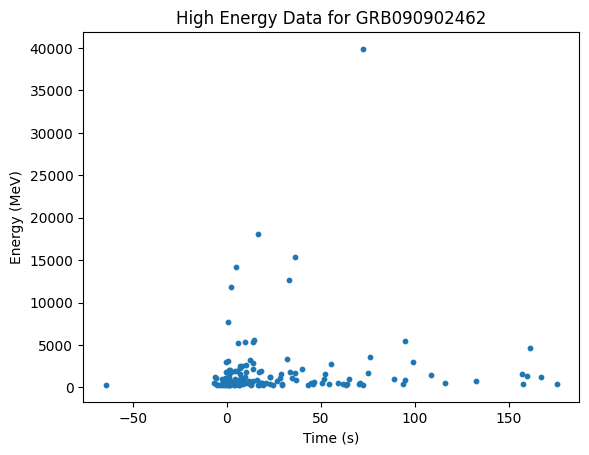

[[72.24638968706131, 16.66811978816986, 36.1077938079834, 4.666591584682465], [39881.582, 18112.428, 15398.656, 14219.388]]


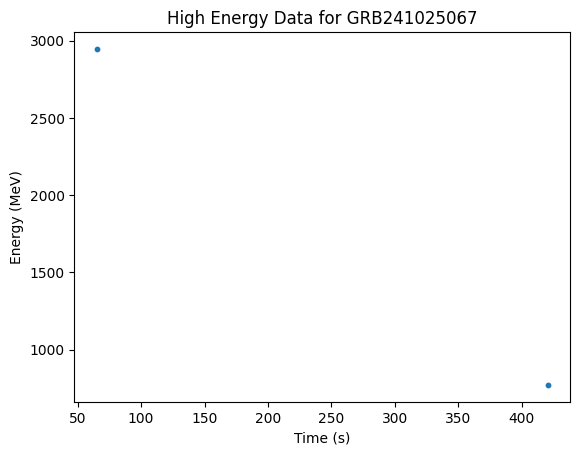

[[65.18006253242493], [2946.2249]]


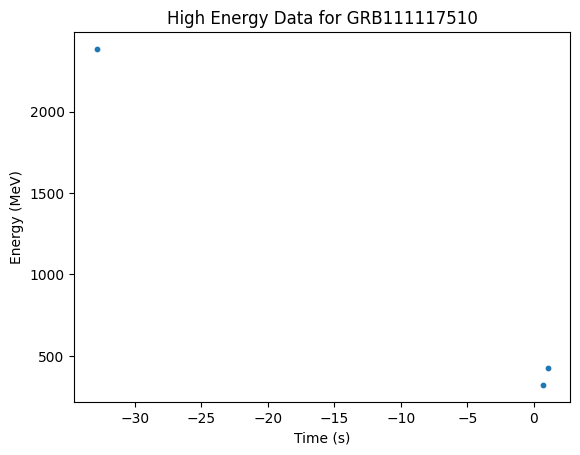

[[-32.8631357550621], [2385.6787]]


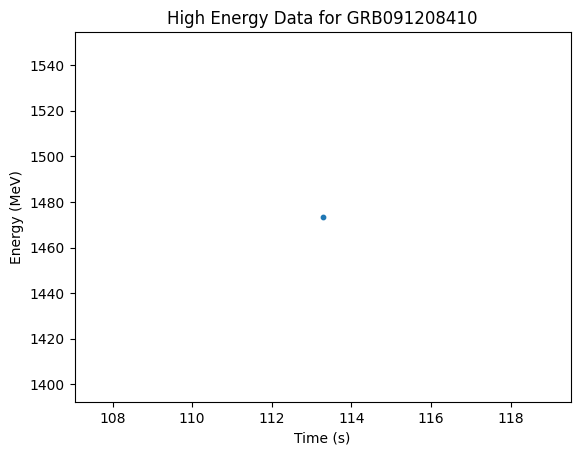

[[113.27451688051224], [1473.4266]]


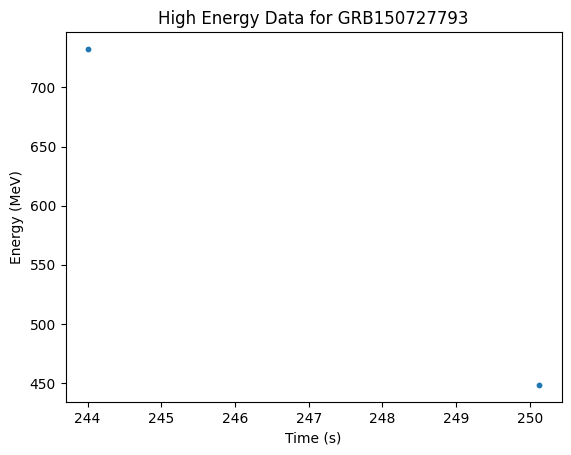

[[244.00901120901108, 250.1252317428589], [732.59033, 448.28702]]
[0, 0]
[0, 0]
[0, 0]


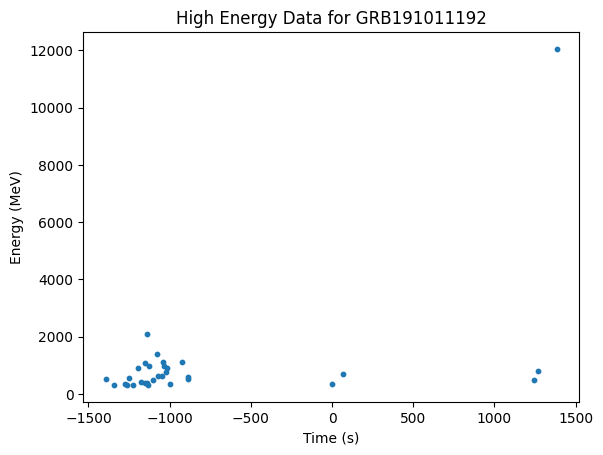

[[1382.548303246498], [12053.775]]
[0, 0]


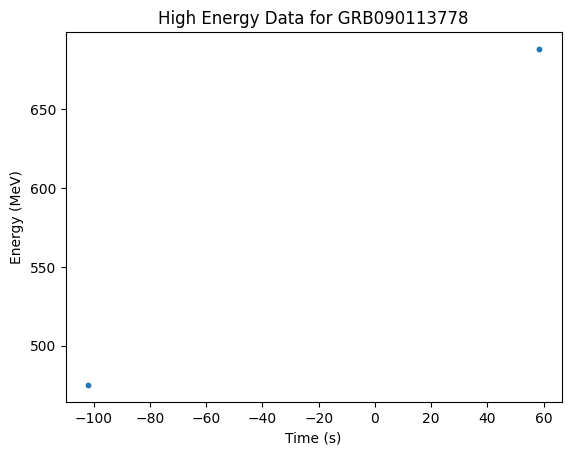

[[58.36215400695801, -101.9286944270134], [688.3384, 475.03976]]


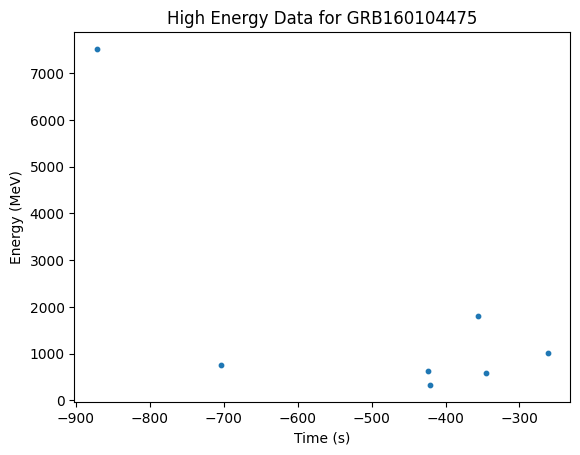

[[-871.6506935954094], [7520.322]]
[0, 0]
[0, 0]
[0, 0]


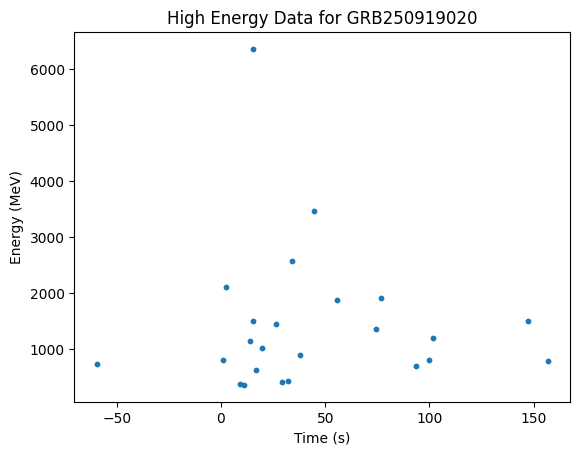

[[15.582310199737549, 44.40961956977844, 33.99918520450592], [6360.4478, 3470.059, 2579.62]]


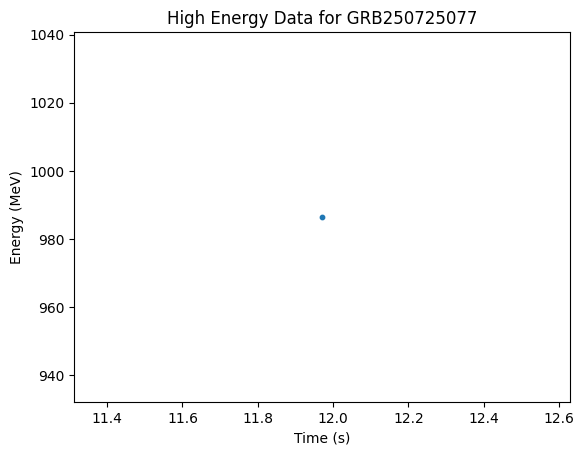

[[11.971566438674927], [986.46875]]
[0, 0]


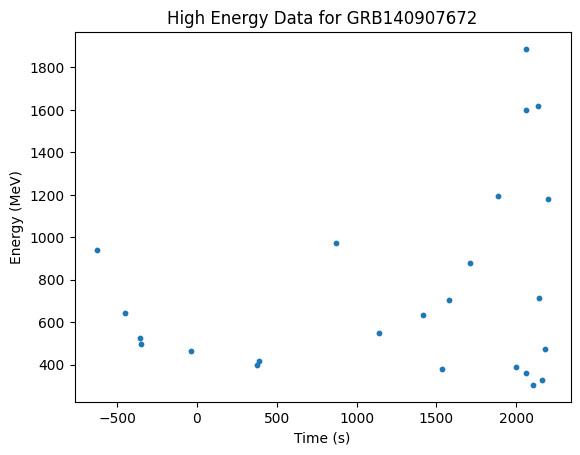

[[2064.9458670020103, 2136.035115778446, 2063.1506667137146, 1884.1367014050484, 2200.05938822031, 870.0495091080666, -626.1113624572754, 1714.2001099586487, 2146.3171083927155, 1577.4870215654373], [1887.3439, 1617.966, 1601.1049, 1193.99, 1181.2832, 971.19714, 940.2738, 877.3152, 714.41364, 703.729]]


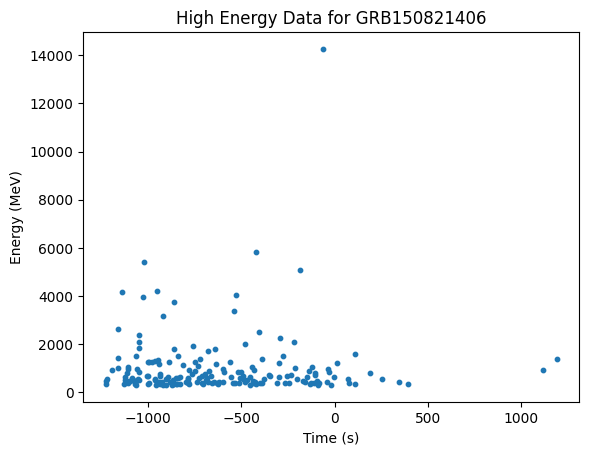

[[-62.025579035282135, -419.5104156136513, -1021.3876326084137, -187.5268918275833], [14259.81, 5824.8115, 5418.9546, 5058.9917]]


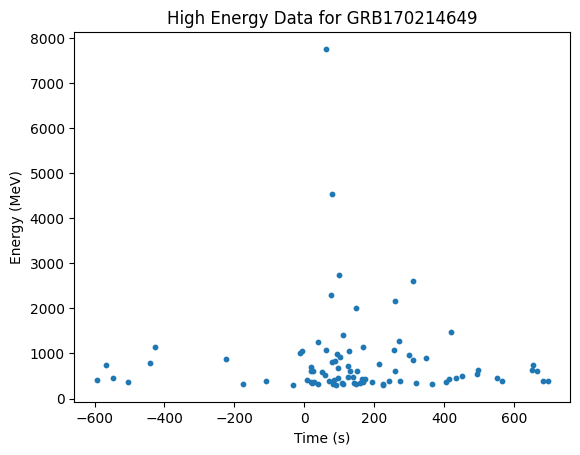

[[61.11867797374725, 78.547278881073, 98.74123269319534], [7759.507, 4532.9243, 2746.1472]]


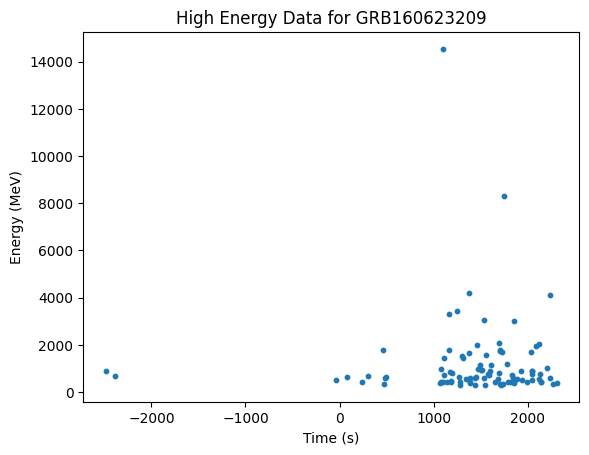

[[1098.1534298062325, 1749.3789306282997], [14539.02, 8321.436]]
[0, 0]


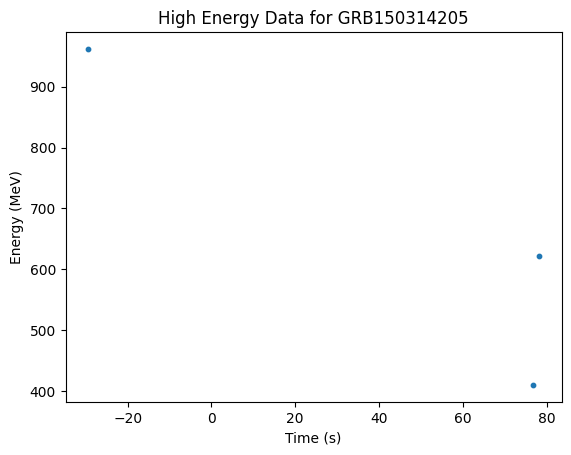

[[-29.408224999904633, 78.20027160644531, 76.70338678359985], [961.7433, 622.1321, 410.6223]]


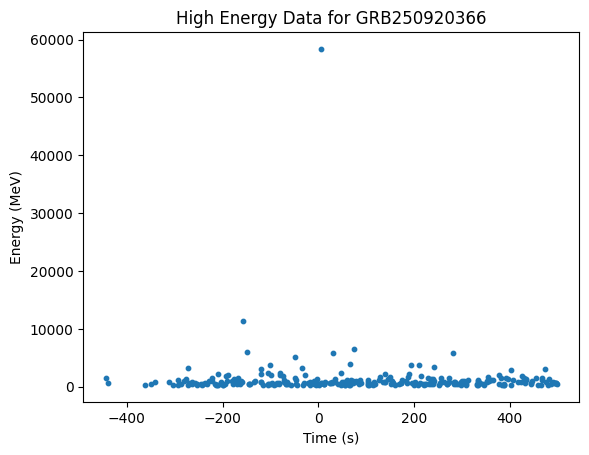

[[5.810939311981201], [58397.46]]
[0, 0]


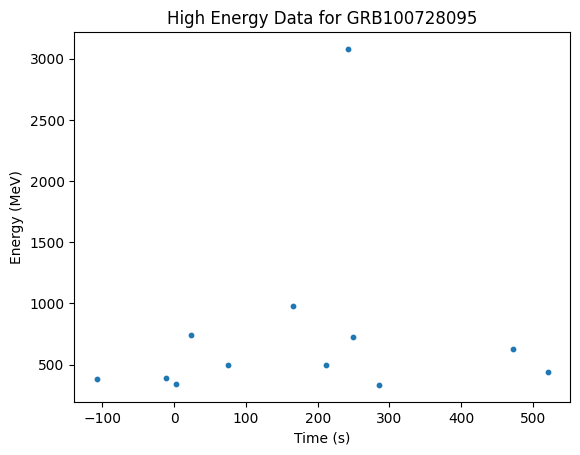

[[242.5610238313675], [3080.3572]]
[0, 0]


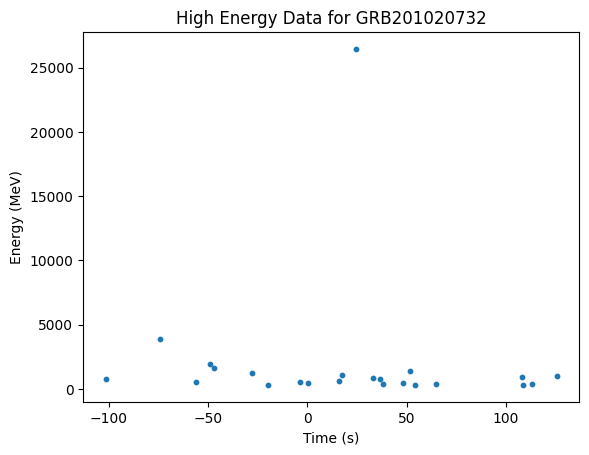

[[24.285063862800598], [26466.54]]
[0, 0]
[0, 0]


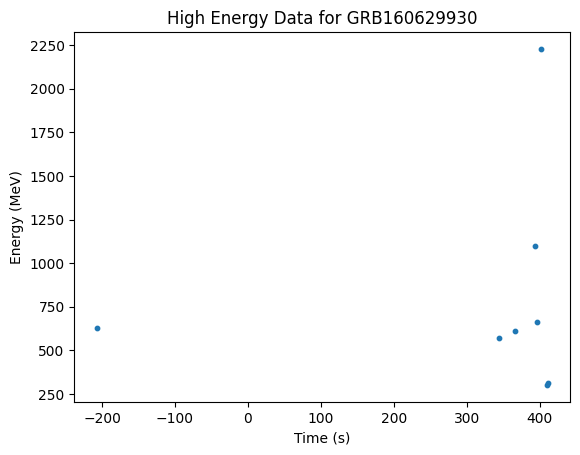

[[401.38159292936325, 393.68144953250885], [2228.5093, 1098.8949]]


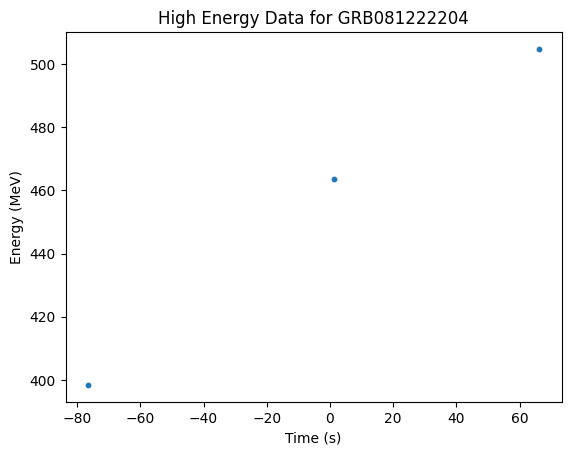

[[66.15816950798035, 1.2450624406337738, -76.4745312333107], [504.73727, 463.7286, 398.4222]]
[0, 0]
[0, 0]
[0, 0]


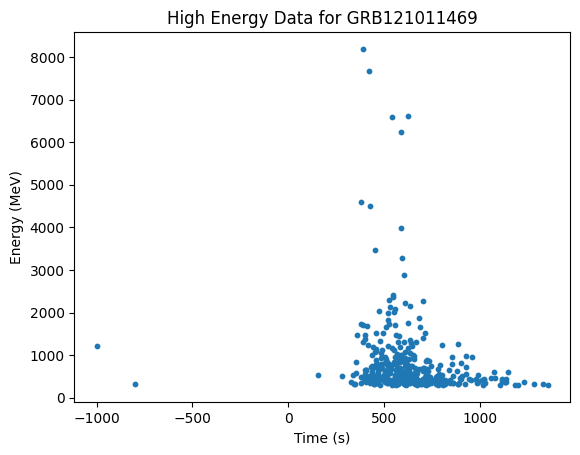

[[392.2176453471184, 421.57750576734543, 625.8359535932541, 542.4252341985703, 590.4314506053925, 378.657717525959, 426.73647779226303, 589.2270321846008, 453.42683362960815, 594.0981420874596, 607.1976951956749], [8187.2783, 7673.4854, 6620.5444, 6598.684, 6230.9897, 4589.6807, 4510.67, 3977.0964, 3475.966, 3268.7998, 2878.8557]]


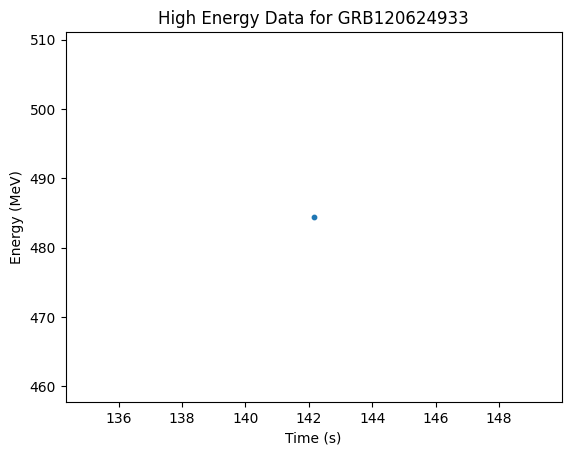

[[142.1516609787941], [484.43958]]


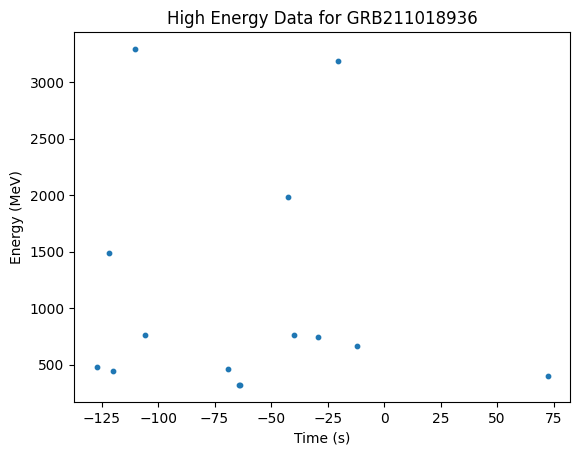

[[-110.0633225440979, -20.39184844493866, -42.676286697387695, -121.52499961853027], [3293.5344, 3183.5767, 1981.7207, 1491.6511]]
[0, 0]


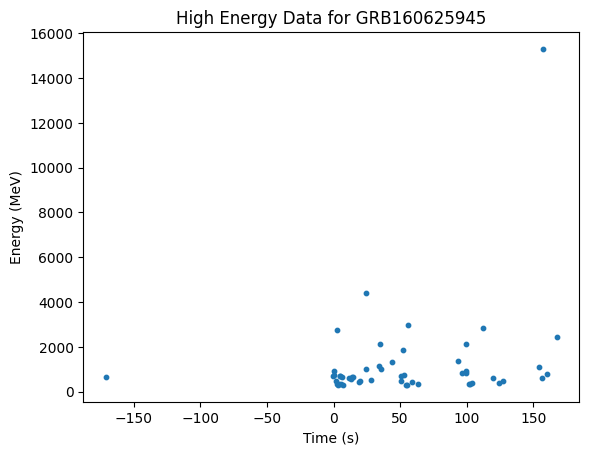

[[157.18135076761246], [15296.706]]


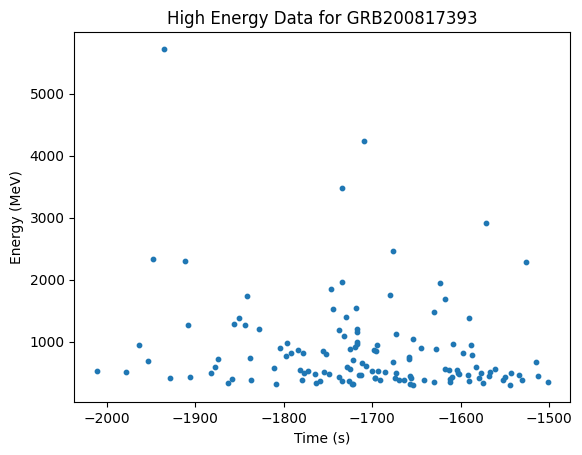

[[-1934.8768351078033, -1709.3980427980423, -1733.8321552276611, -1570.7893919944763, -1676.449805855751, -1947.6290327310562, -1910.9802597761154, -1526.2920725345612], [5720.4556, 4232.489, 3481.6953, 2915.0613, 2466.4397, 2331.8315, 2307.2078, 2281.5388]]


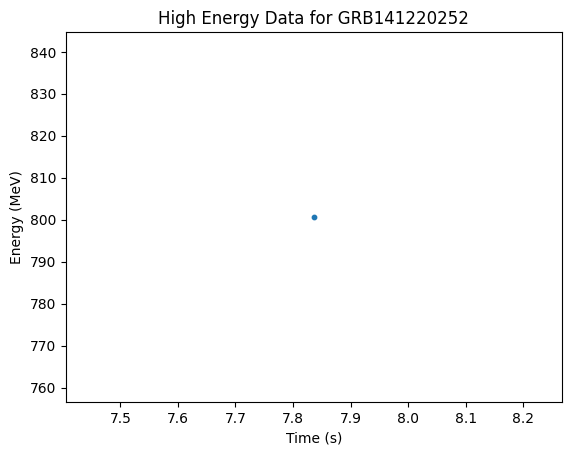

[[7.836046516895294], [800.658]]
[0, 0]


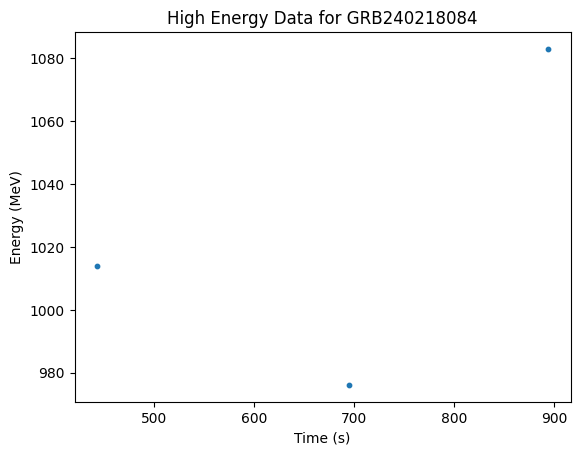

[[894.1185731887817, 442.99947011470795, 695.1839306354523], [1082.8716, 1013.9142, 976.1352]]
[0, 0]
[0, 0]
[0, 0]
[0, 0]


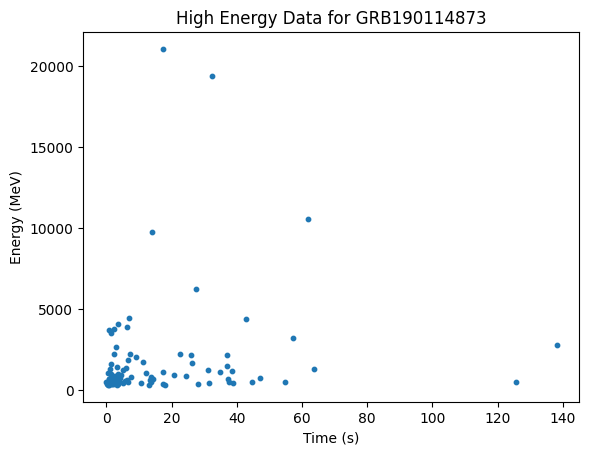

[[17.430248975753784, 32.46861982345581, 61.864662528038025, 13.958243608474731], [21049.945, 19361.498, 10537.359, 9758.221]]
[0, 0]
[0, 0]


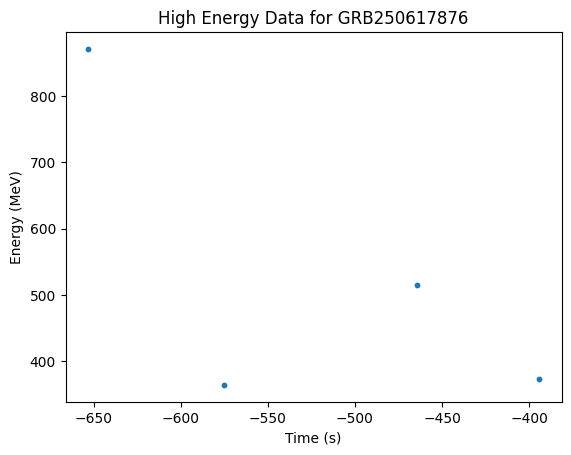

[[-653.1609725952148, -464.5752184391022, -394.2515957355499, -575.0514589548111], [871.49695, 515.08765, 372.6972, 363.8551]]


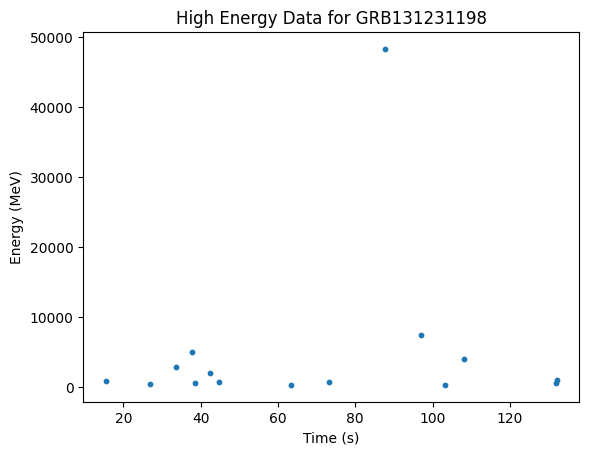

[[87.78932124376297], [48294.992]]
[0, 0]
[0, 0]


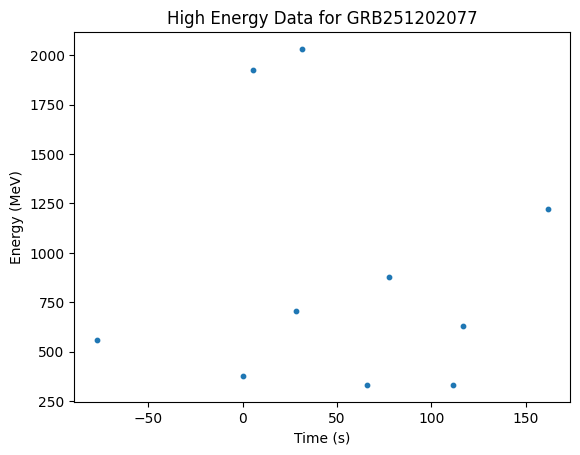

[[31.627503752708435, 5.321880102157593, 161.69712090492249, 77.39980709552765], [2031.8033, 1923.9606, 1222.9253, 876.71985]]


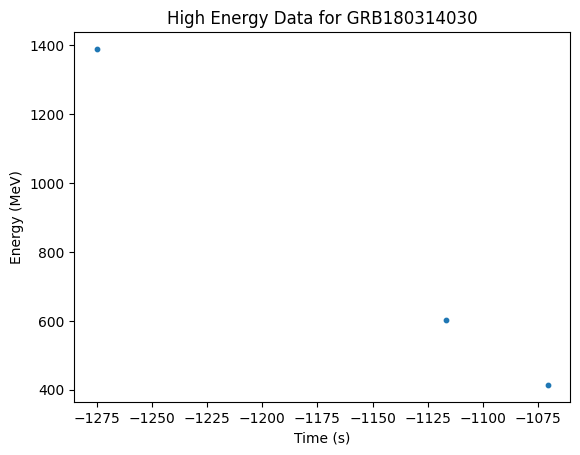

[[-1274.9334099292755, -1116.878272652626], [1389.5641, 603.4898]]
[0, 0]


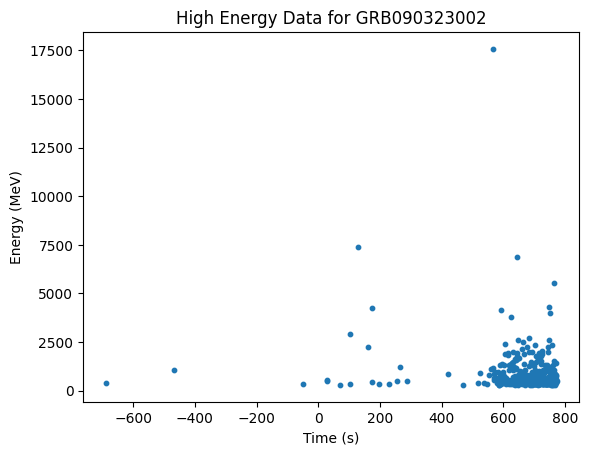

[[565.1880936920643, 129.41926872730255, 643.24980032444], [17568.012, 7401.676, 6850.092]]


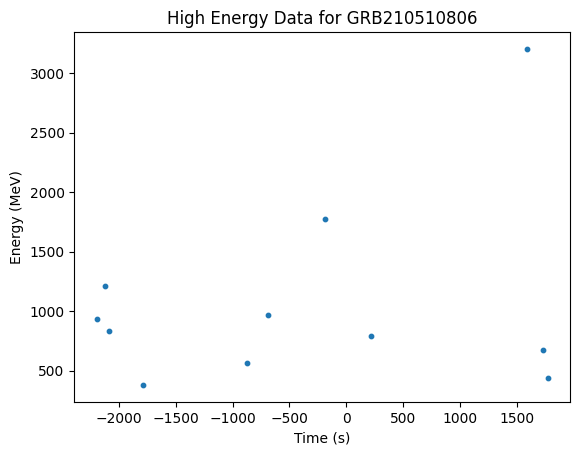

[[1584.3236478567123, -188.75896537303925, -2122.2134070396423], [3201.7253, 1773.6227, 1213.343]]
[0, 0]
[0, 0]


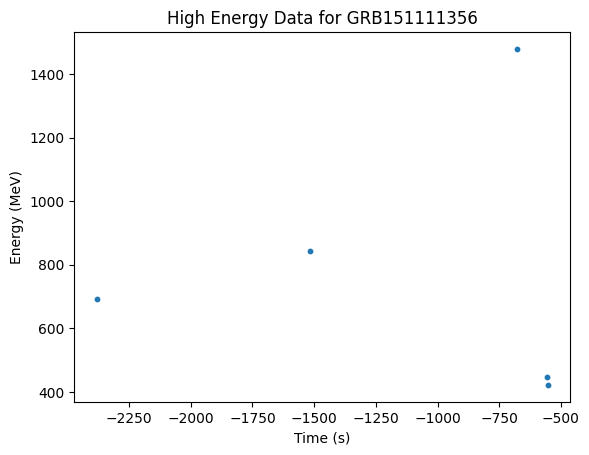

[[-677.2116214036942, -1515.2585114240646, -2379.977030158043], [1478.4633, 844.4241, 692.323]]


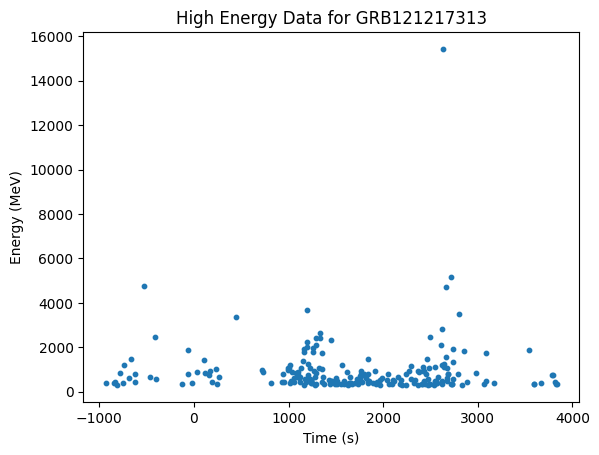

[[2634.535242795944], [15433.022]]


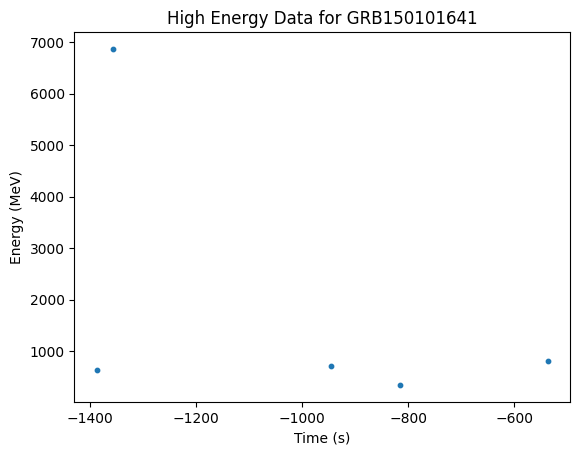

[[-1355.8720280528069], [6868.2295]]


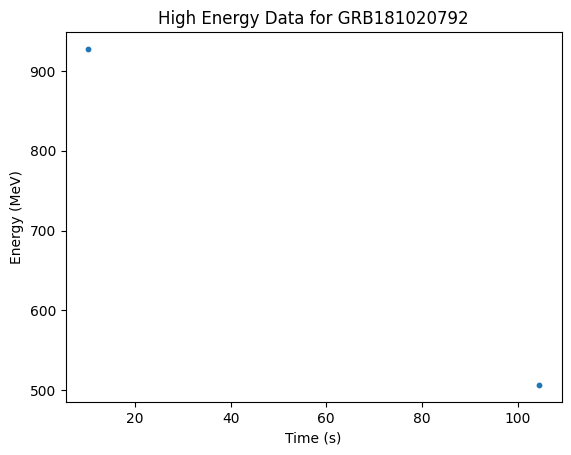

[[10.233132719993591, 104.47706615924835], [927.46625, 506.76242]]


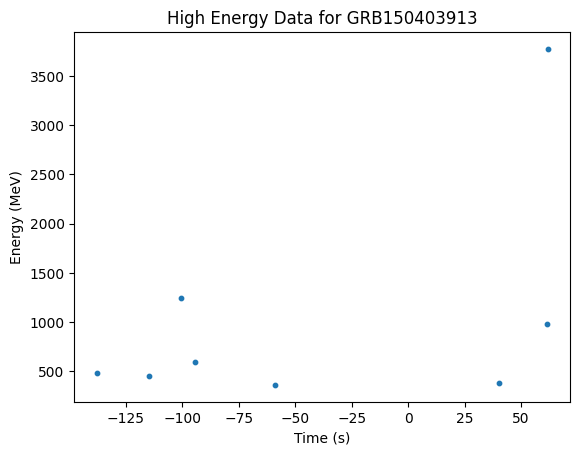

[[61.86953455209732], [3776.5127]]


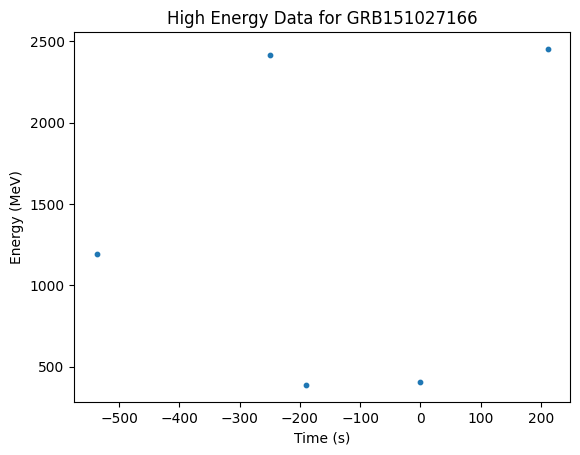

[[211.47446238994598, -249.94182205200195, -536.9033196568489], [2452.371, 2418.0925, 1194.6066]]
[0, 0]
[0, 0]
[0, 0]


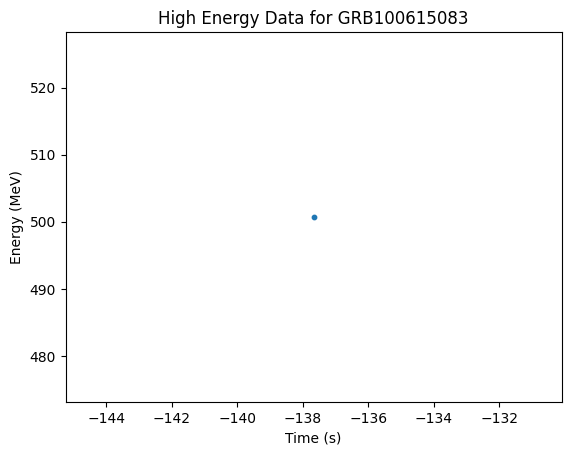

[[-137.66455858945847], [500.72247]]


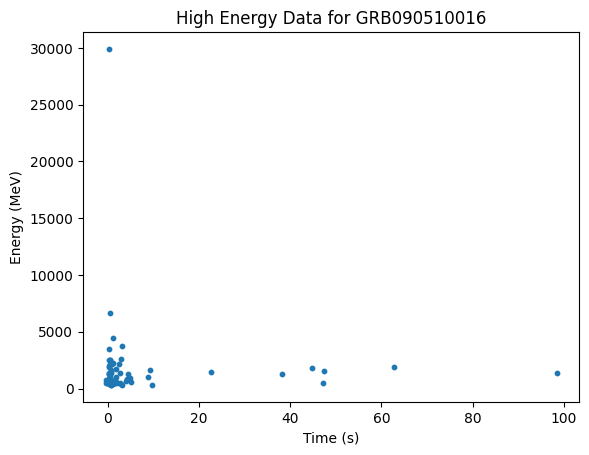

[[0.3282289206981659], [29914.78]]


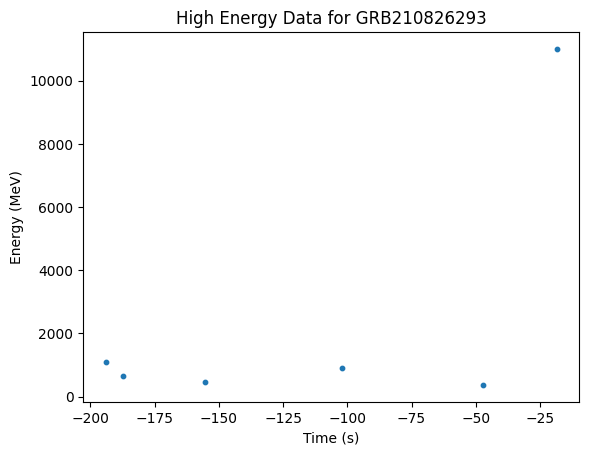

[[-18.539083123207092], [11006.102]]


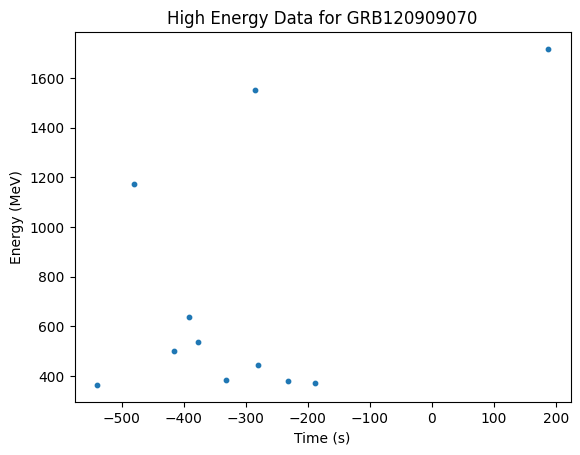

[[187.35851228237152, -284.6371695995331, -481.3444014787674, -391.3263636827469], [1717.2185, 1553.6031, 1174.0348, 636.38464]]


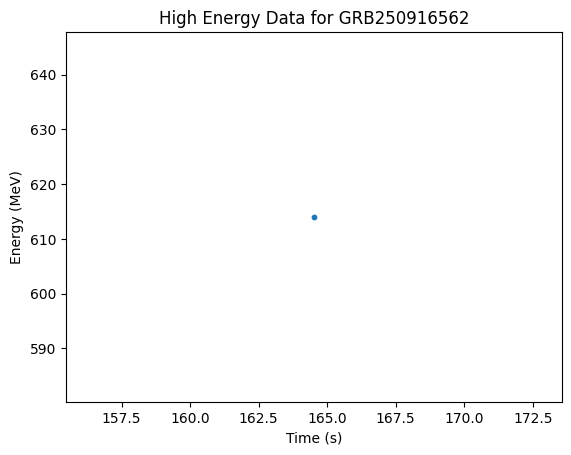

[[164.51216614246368], [614.0052]]


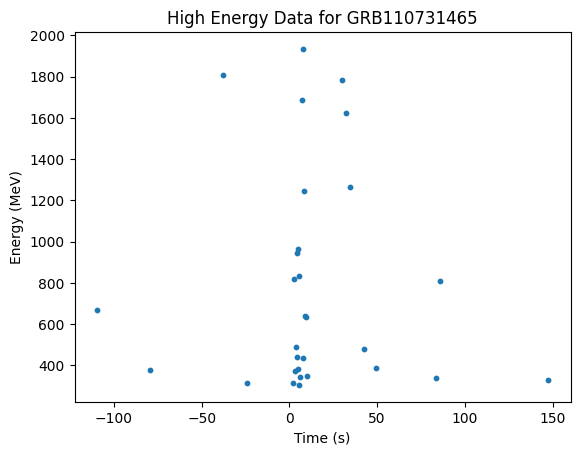

[[7.769622564315796, -37.80041617155075, 29.78793329000473, 7.353889763355255, 32.10241615772247, 34.791661500930786, 8.425446689128876, 5.017275393009186, 4.450646817684174, 5.325503945350647, 2.6865063309669495, 85.694100856781], [1934.5631, 1806.4038, 1785.4713, 1689.2205, 1623.804, 1266.9073, 1244.3257, 965.32916, 945.7597, 833.9902, 817.077, 810.6221]]


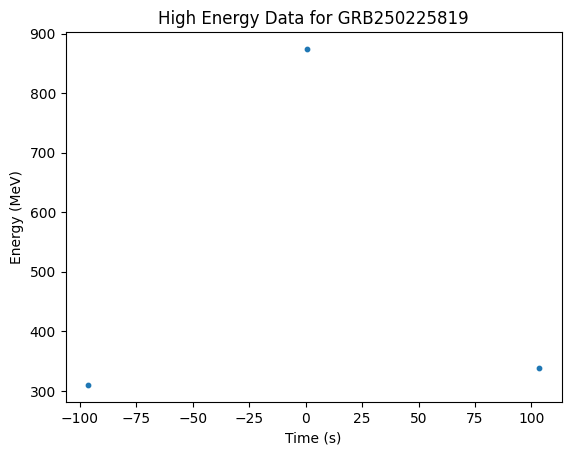

[[0.6608091592788696, 103.41102814674377, -96.31429135799408], [874.53827, 337.85287, 309.86584]]
[0, 0]
[0, 0]


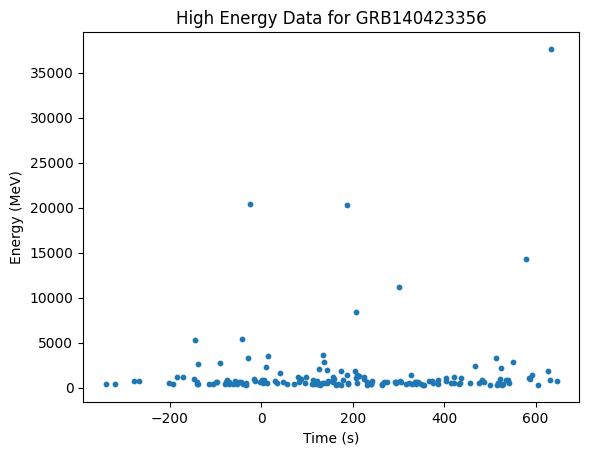

[[633.2822801470757, -23.688590049743652, 187.91333973407745, 578.2669811844826], [37635.67, 20359.645, 20240.46, 14295.31]]


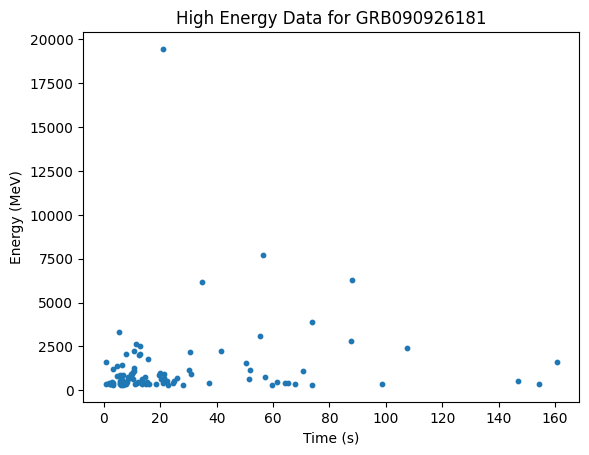

[[20.838427662849426, 56.28753399848938], [19459.947, 7719.7227]]


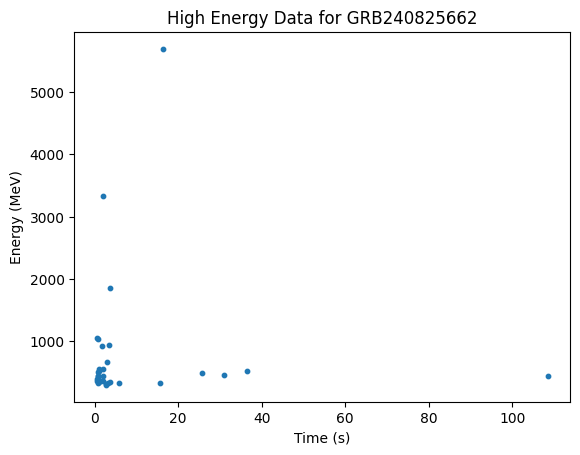

[[16.25052535533905, 1.9454278945922852], [5693.5, 3335.2676]]


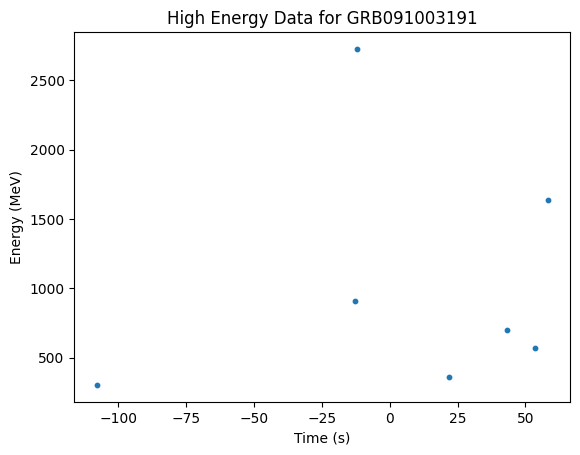

[[-12.032884895801544, 58.28052979707718], [2726.0422, 1637.9058]]


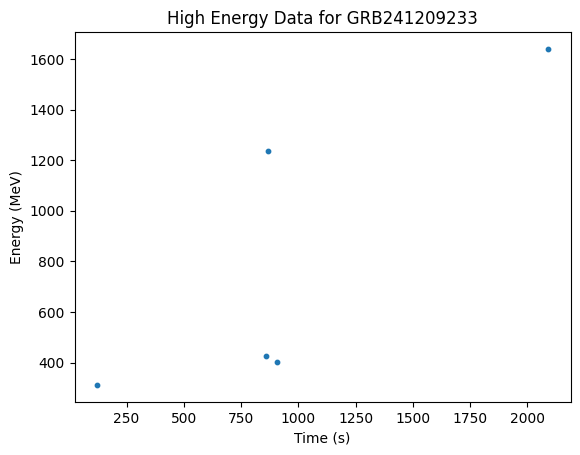

[[2090.360181927681, 866.4460273981094], [1639.4578, 1237.3174]]


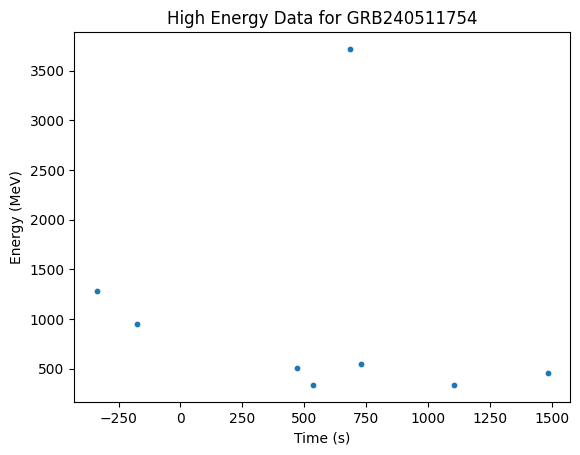

[[687.0228880643845], [3719.8967]]


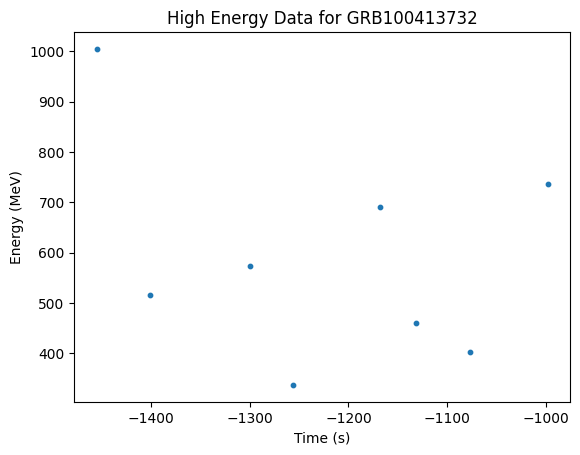

[[-1454.2009164094925, -998.5010049343109, -1168.4532923102379, -1299.1804260611534, -1400.8727071881294, -1131.8424209356308, -1077.3409186601639], [1004.79877, 737.20636, 690.7106, 572.76404, 515.3881, 459.80252, 402.60294]]


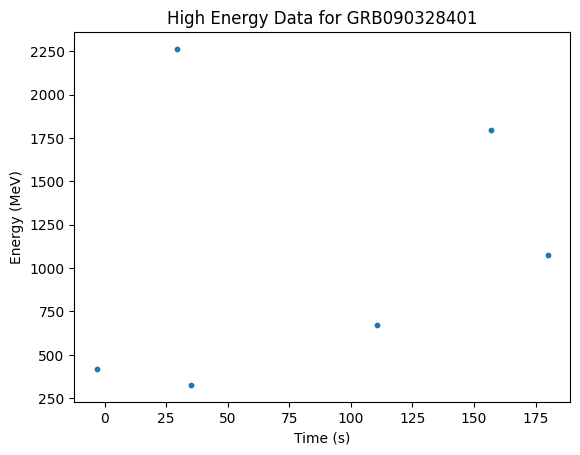

[[29.297758907079697, 156.96793520450592, 179.95009049773216], [2263.1687, 1797.4052, 1074.6674]]
[0, 0]
[0, 0]
[0, 0]


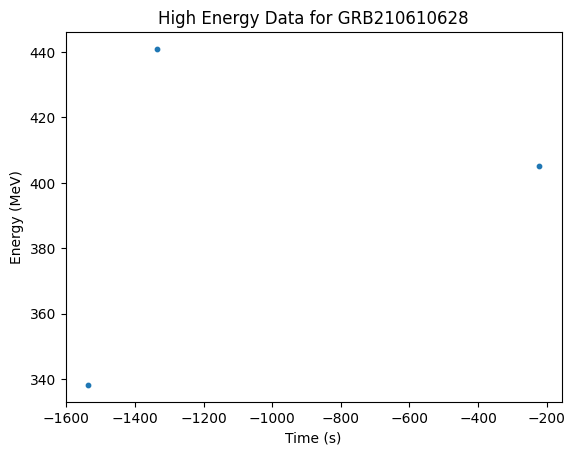

[[-1335.1137738227844, -222.323899269104, -1536.1947520971298], [440.9179, 405.1889, 338.25238]]
[0, 0]


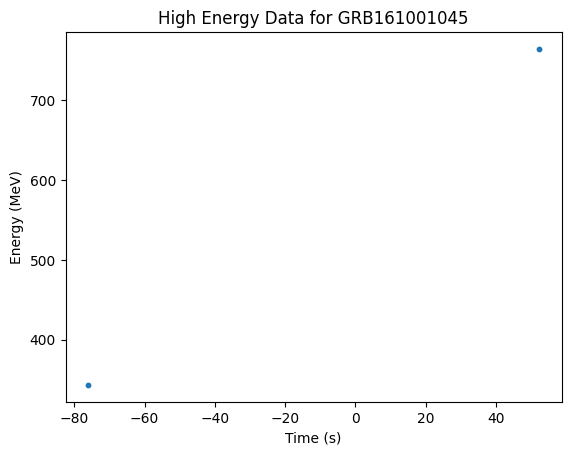

[[52.24869084358215, -76.05969160795212], [764.58575, 343.19333]]


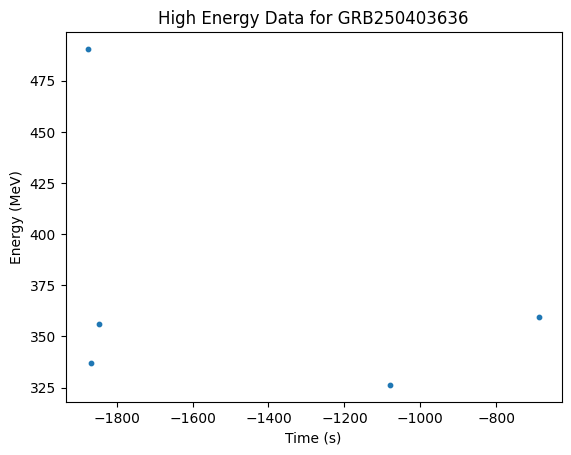

[[-1874.9734091758728, -687.8062142133713, -1845.7247203588486, -1866.5169751644135, -1081.3226047754288], [490.57315, 359.6429, 356.2389, 336.92017, 326.27615]]
[0, 0]
[0, 0]


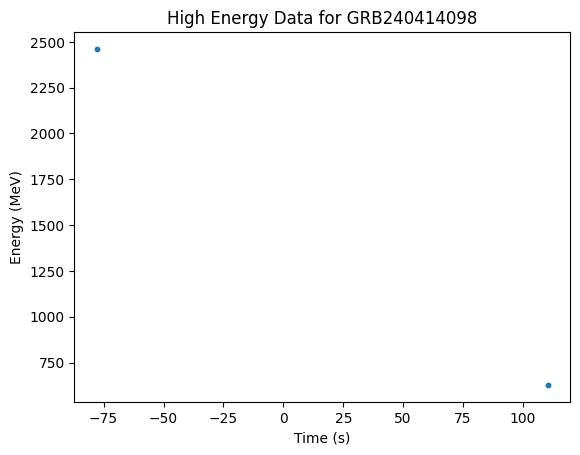

[[-77.76857280731201], [2461.5962]]


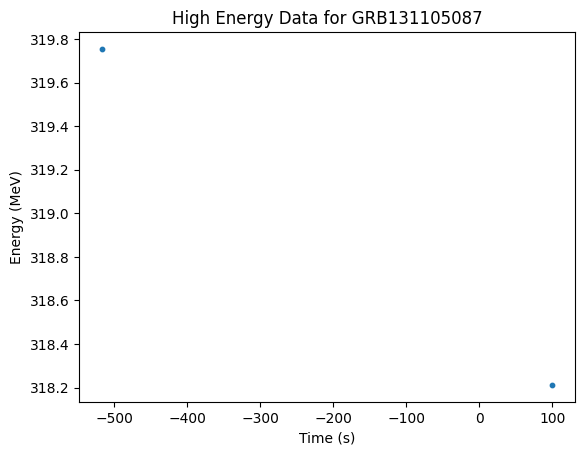

[[-517.4455159902573, 100.28314292430878], [319.75433, 318.2121]]


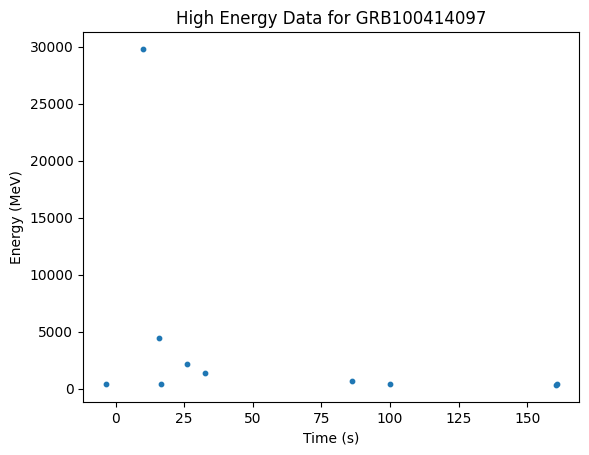

[[9.868479192256927], [29802.994]]


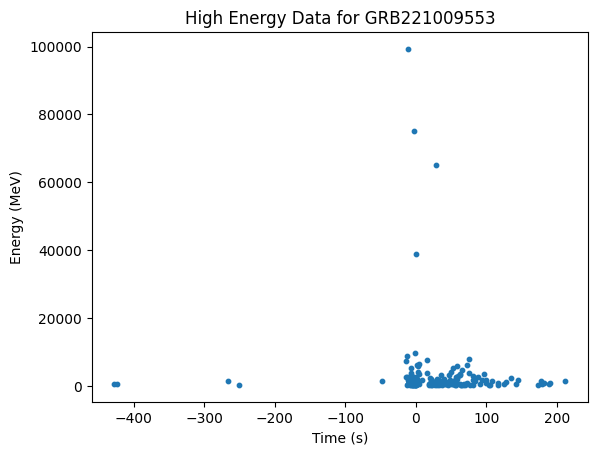

[[-10.661797642707825, -2.57060444355011, 28.34434962272644, 0.7262215614318848], [99325.36, 75156.18, 64973.117, 38901.035]]


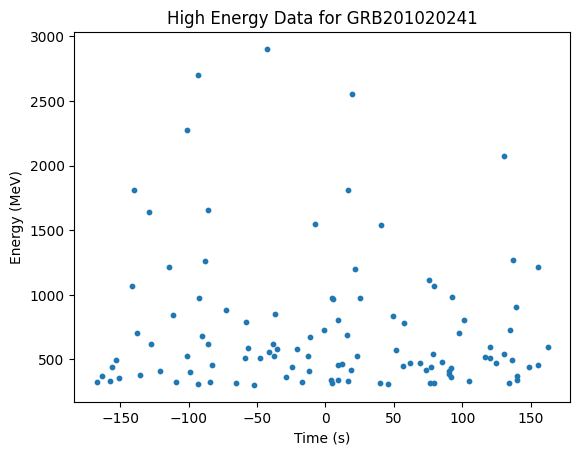

[[-42.403313636779785, -92.76117515563965, 19.70128357410431, -101.26203739643097, 130.74553060531616, -139.73529148101807, 16.193926692008972, -85.58039891719818, -128.926704287529, -7.449172139167786, 40.70747125148773, 136.756849527359, -88.10921001434326, 155.55249619483948, -114.39234375953674, 21.30064022541046, 75.95300281047821, -141.16871285438538, 79.53005826473236], [2901.652, 2701.9119, 2554.3162, 2276.9812, 2069.9456, 1807.8845, 1807.5024, 1652.663, 1638.5049, 1544.9675, 1543.448, 1269.8326, 1259.5168, 1218.0076, 1214.614, 1202.217, 1113.3263, 1066.0276, 1065.2587]]
[0, 0]
[0, 0]


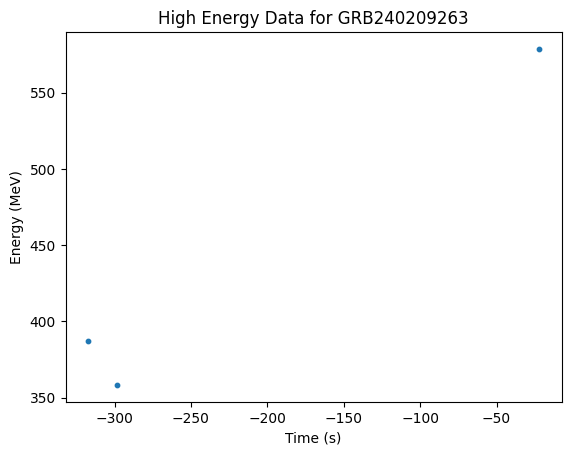

[[-22.26126718521118, -317.3059768676758, -298.69029927253723], [578.6122, 386.91626, 358.3484]]
[0, 0]


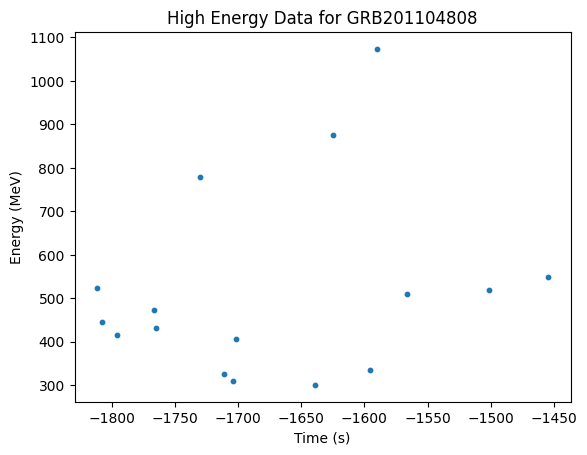

[[-1589.7954366207123, -1624.9314914941788, -1729.9442851543427, -1454.790401816368, -1811.4673517942429, -1501.6521910429, -1566.0066421031952, -1766.6396119594574, -1807.2493360042572, -1764.8704924583435, -1795.982658982277, -1701.3424657583237], [1073.6466, 875.96124, 780.0464, 548.0041, 523.8832, 518.3812, 510.71655, 473.05005, 446.354, 430.82758, 415.64746, 405.45905]]
[0, 0]
[0, 0]
[0, 0]


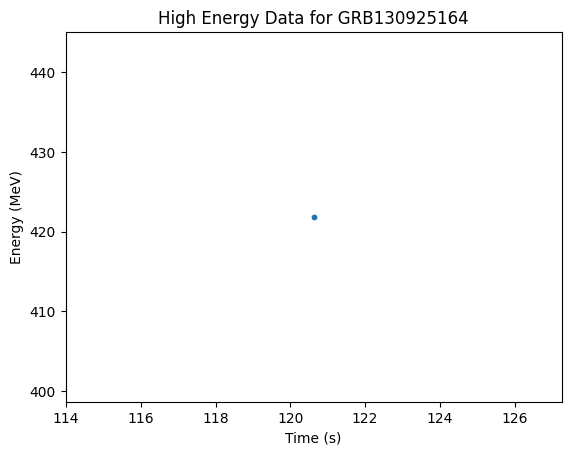

[[120.62389016151428], [421.85022]]


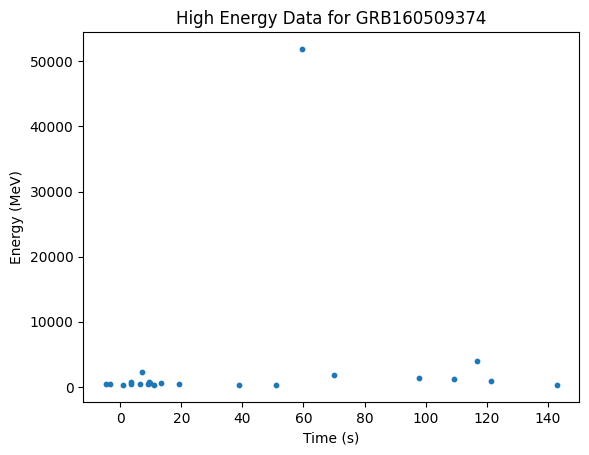

[[59.50649231672287], [51898.188]]


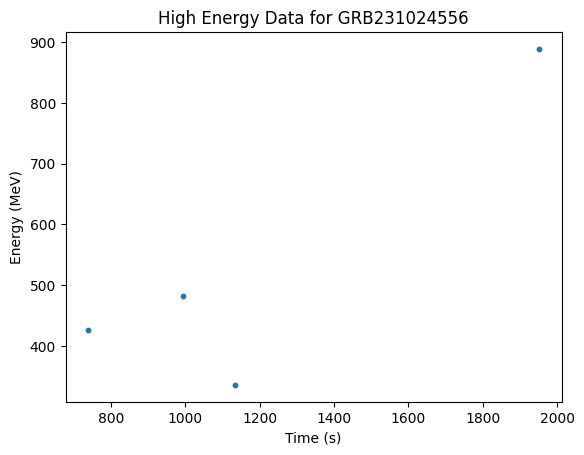

[[1951.3026651144028, 993.7746061086655, 738.9126858711243, 1133.7327258586884], [888.84534, 482.44516, 426.86118, 335.9796]]


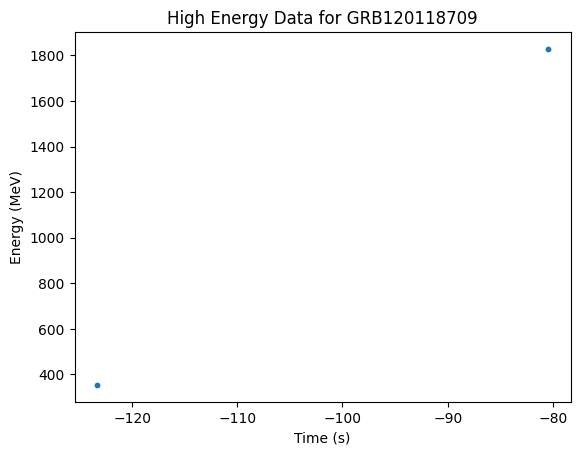

[[-80.46392959356308], [1828.7992]]


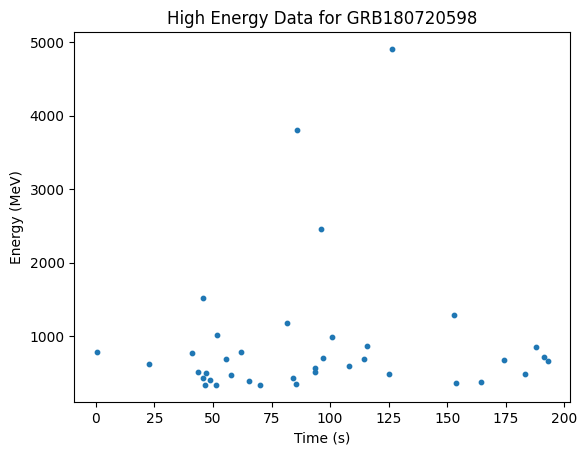

[[126.4212954044342, 85.89945459365845, 96.27063977718353], [4907.434, 3797.5654, 2450.5994]]


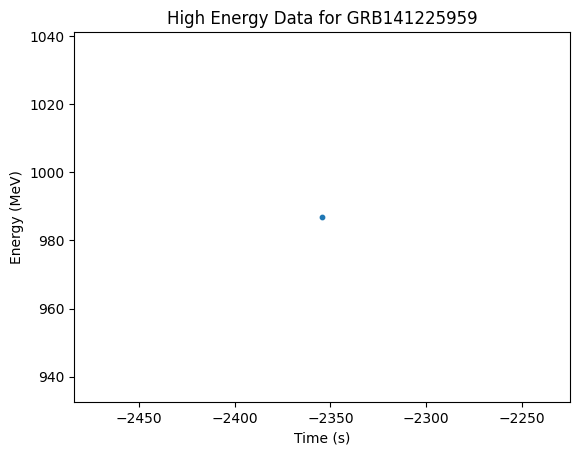

[[-2354.167160630226], [986.91144]]
[0, 0]


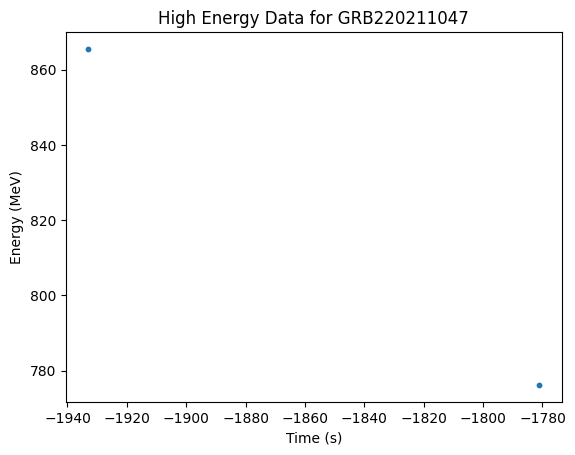

[[-1932.981748342514, -1781.0953608751297], [865.4998, 776.1702]]
[0, 0]
[0, 0]


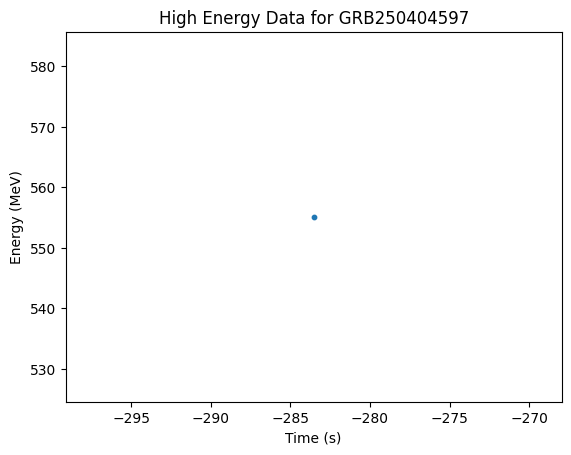

[[-283.5429811477661], [555.12805]]
[0, 0]


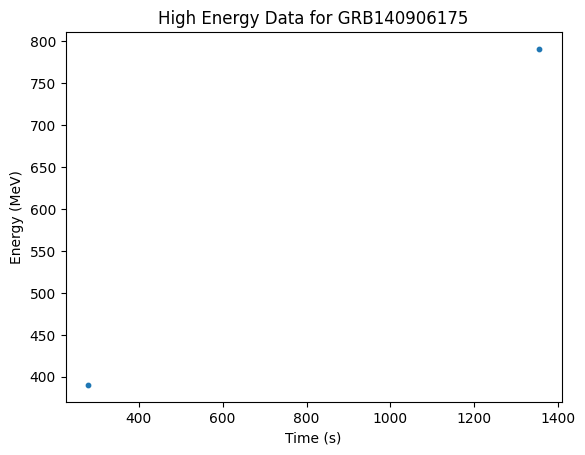

[[1354.5367416739464, 279.43453109264374], [790.62573, 390.2893]]


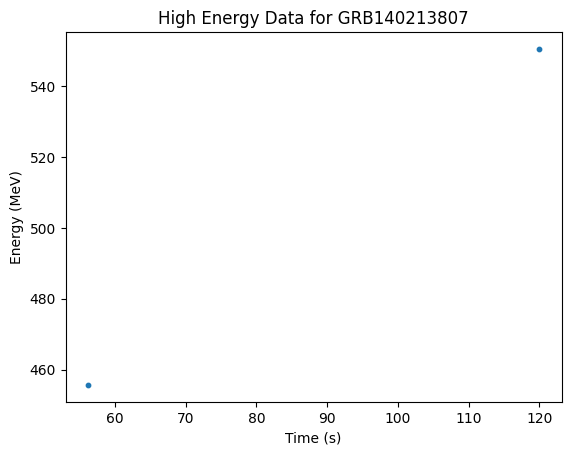

[[119.94537281990051, 56.24303561449051], [550.5452, 455.67035]]


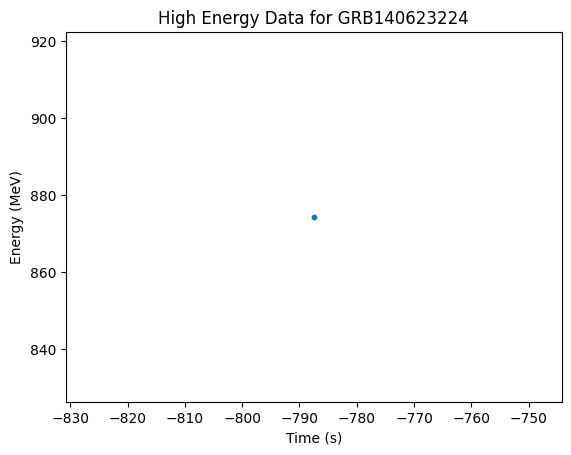

[[-787.5038412213326], [874.32983]]
[0, 0]


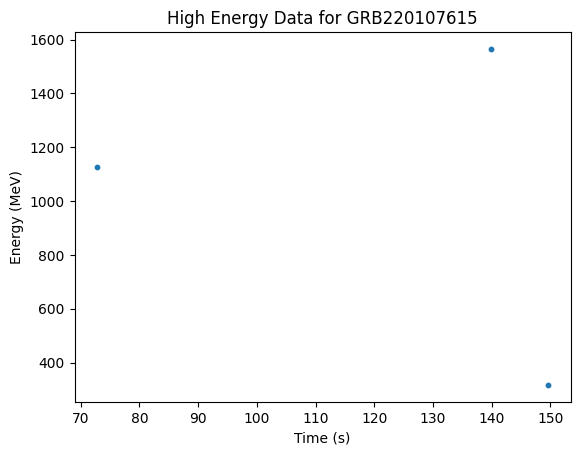

[[139.8544224500656, 72.79492652416229], [1565.4899, 1125.0995]]
[0, 0]


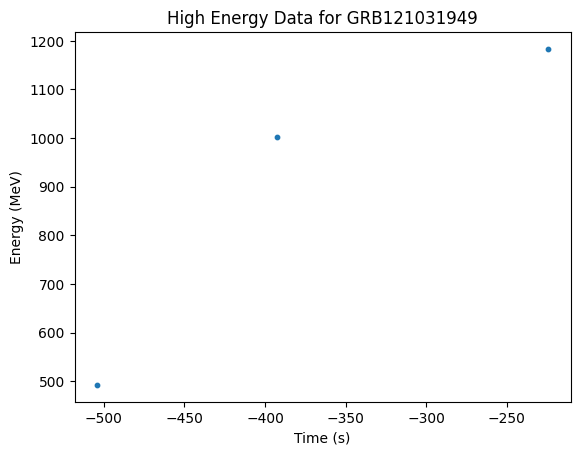

[[-224.4480442404747, -392.7226665019989, -504.18028485774994], [1183.3986, 1002.7541, 492.43338]]


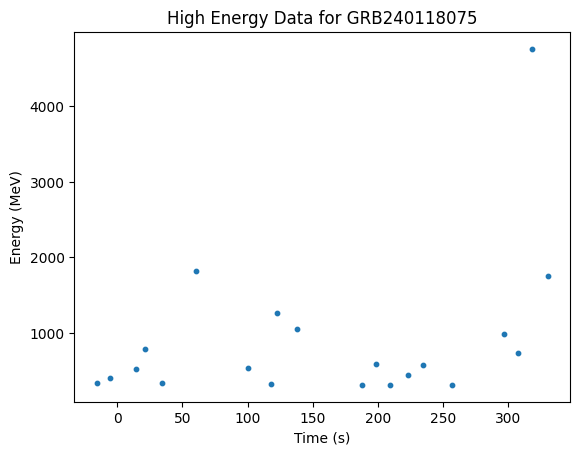

[[318.3099480867386, 60.179996967315674, 330.26582634449005], [4760.6724, 1816.7173, 1754.1073]]


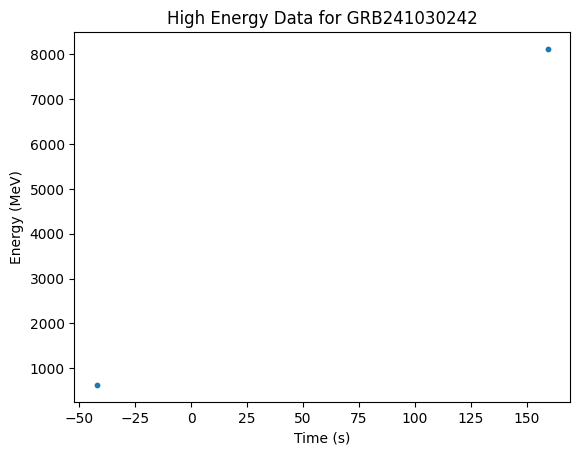

[[159.3330649137497], [8123.491]]


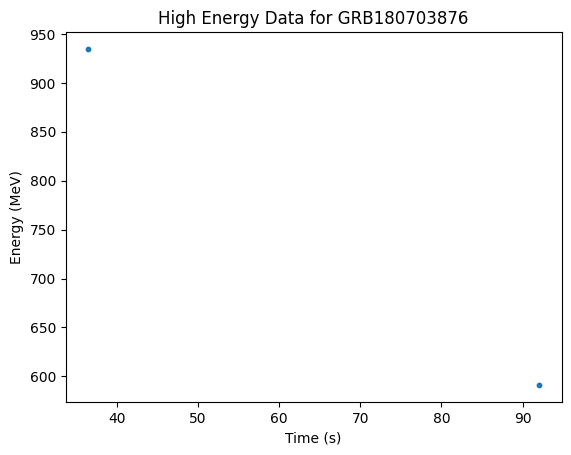

[[36.45019519329071, 92.04669153690338], [934.6721, 591.29333]]
[0, 0]


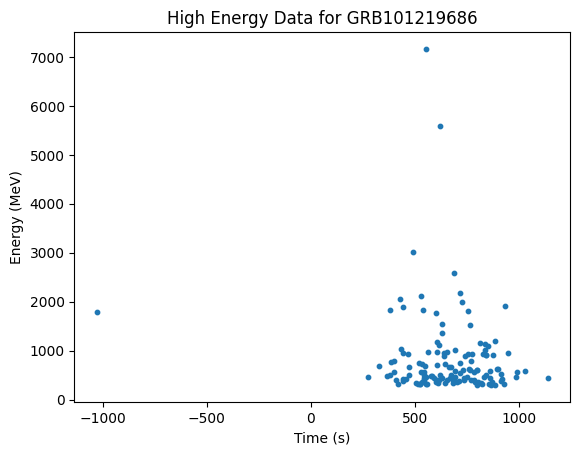

[[554.4165107011795, 621.7093519568443, 490.8283138871193, 684.5437279939651], [7162.63, 5591.4683, 3016.1938, 2588.056]]


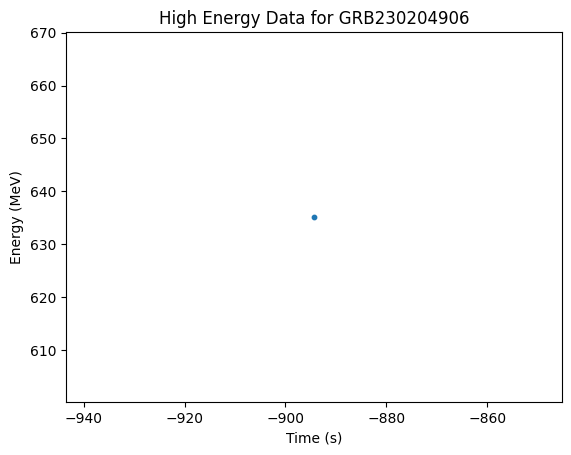

[[-894.38598549366], [635.15735]]
[0, 0]


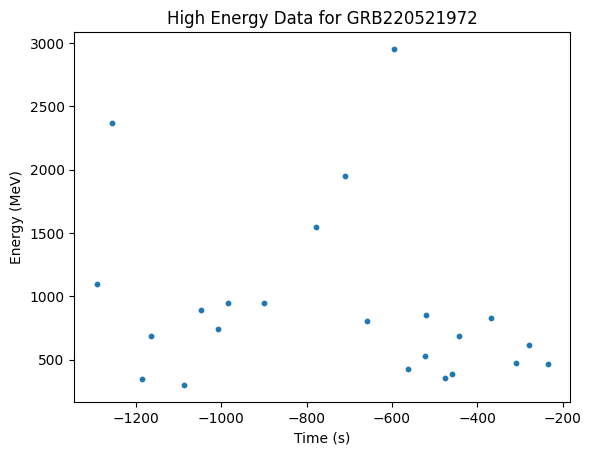

[[-595.5394345521927, -1256.9466992616653, -711.1444642543793, -778.1817300319672, -1291.7838453054428], [2952.5188, 2366.0806, 1947.532, 1549.912, 1094.3738]]
[0, 0]
[0, 0]


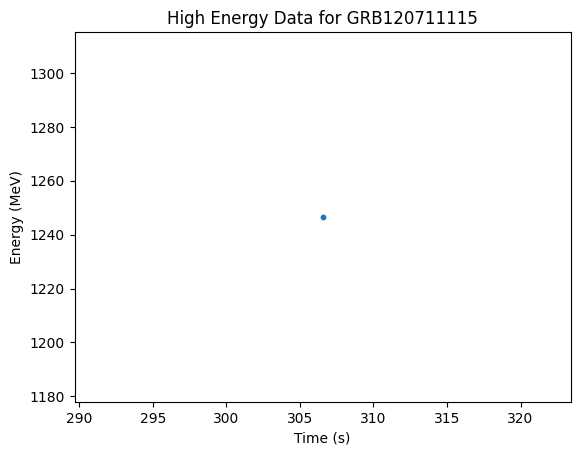

[[306.54585498571396], [1246.561]]
[0, 0]
[0, 0]
[0, 0]


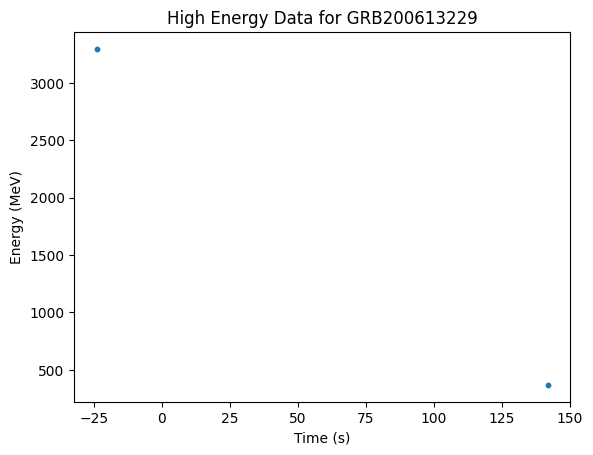

[[-23.79813575744629], [3296.3494]]
[0, 0]
[0, 0]
[0, 0]


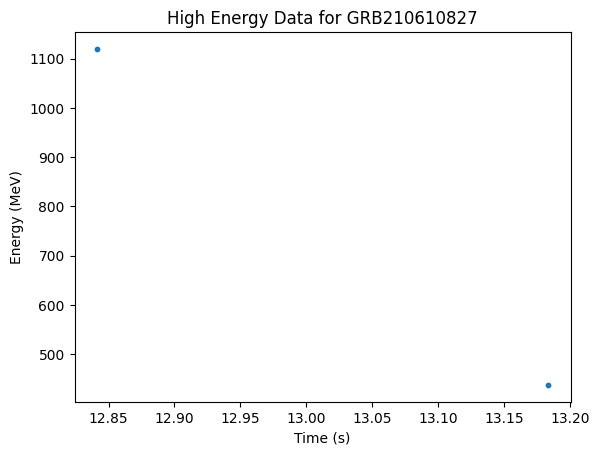

[[12.84131407737732, 13.183483600616455], [1120.0383, 437.21307]]
[0, 0]
[0, 0]
[0, 0]


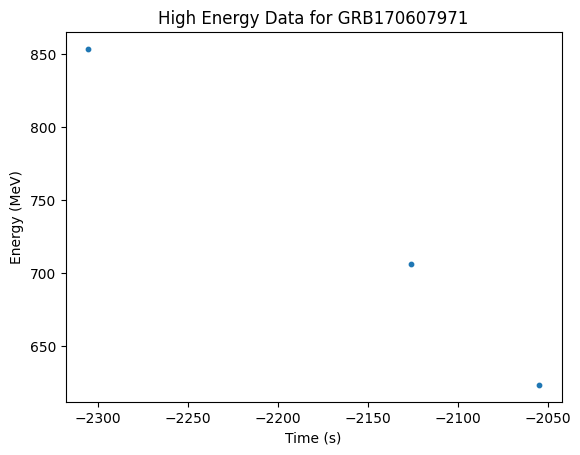

[[-2305.48384475708, -2125.8152945041656, -2054.763278245926], [853.33844, 706.69763, 623.7405]]
[0, 0]
[0, 0]
[0, 0]


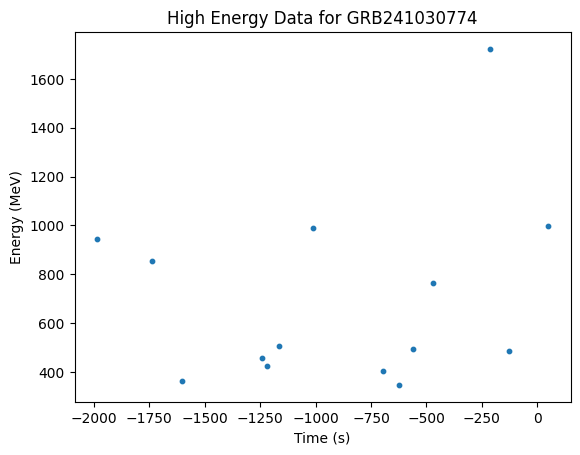

[[-213.83789598941803, 48.51345074176788, -1013.2261760234833, -1986.0023822784424, -1739.1734716892242, -469.14187121391296], [1722.7074, 999.02325, 989.2905, 942.4878, 855.4073, 764.43384]]


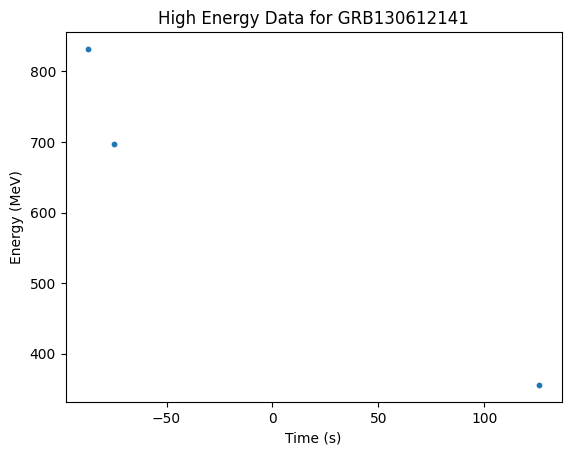

[[-87.0135748386383, -75.06065171957016, 125.97022187709808], [831.9696, 697.29626, 355.5606]]
[0, 0]


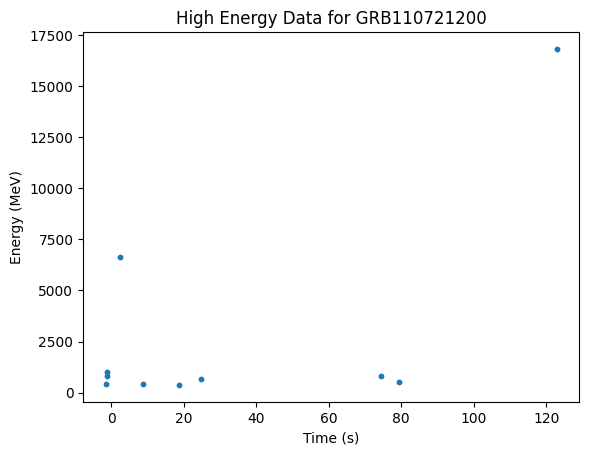

[[122.82495582103729, 2.495623528957367], [16809.158, 6652.8354]]


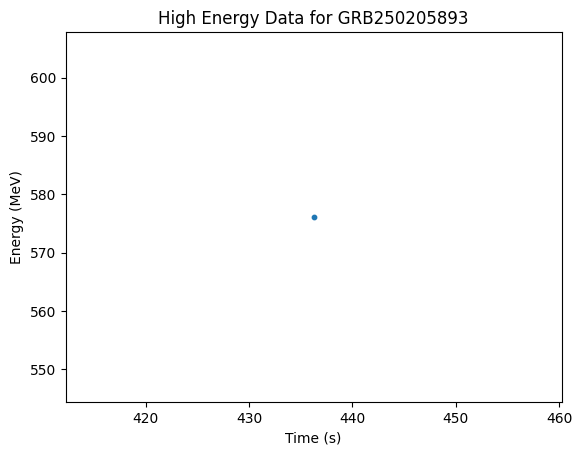

[[436.2426676750183], [576.101]]
[0, 0]


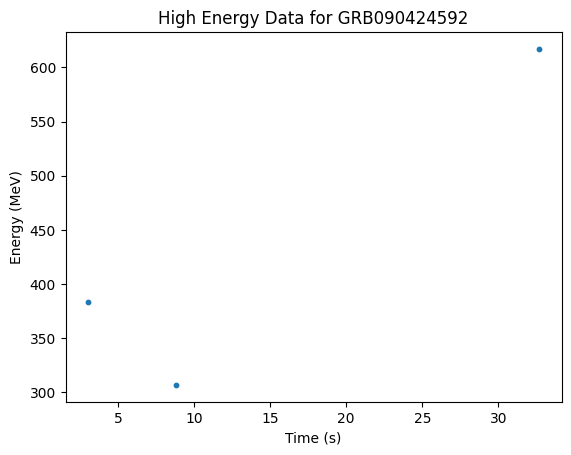

[[32.683216363191605, 3.0294823944568634, 8.81565460562706], [617.02264, 383.34937, 306.7538]]


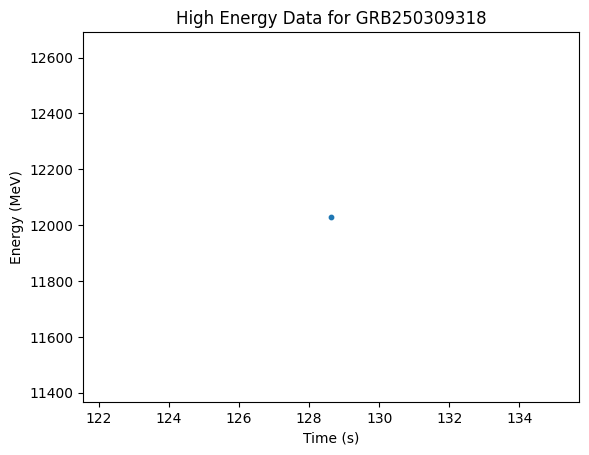

[[128.63607513904572], [12029.503]]


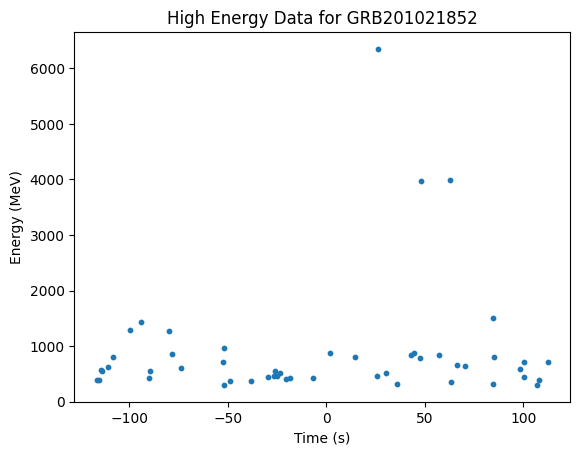

[[26.206181287765503, 62.52315175533295, 48.00837206840515], [6349.3726, 3983.3005, 3965.8728]]
[0, 0]


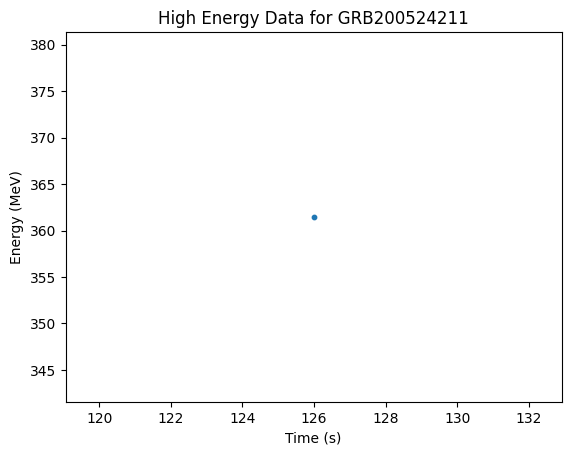

[[125.98894822597504], [361.46255]]
[0, 0]


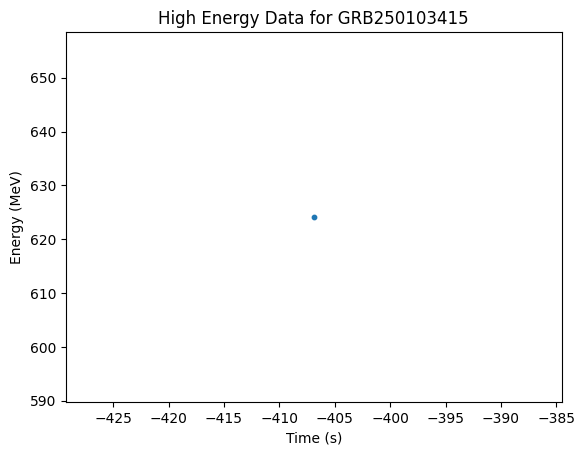

[[-406.8911671638489], [624.14325]]


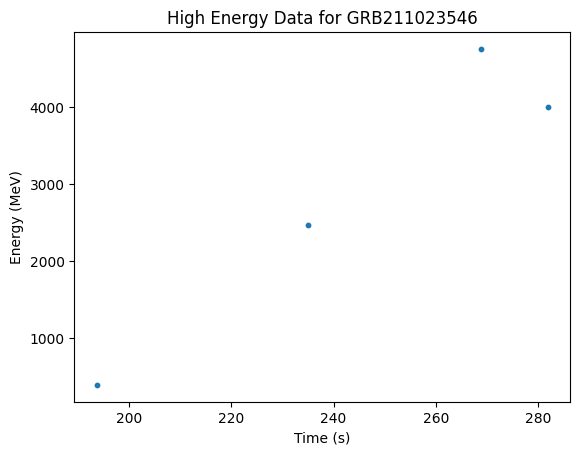

[[268.8456267118454, 281.9494479894638, 235.08303821086884], [4751.271, 3994.8557, 2462.2974]]
[0, 0]


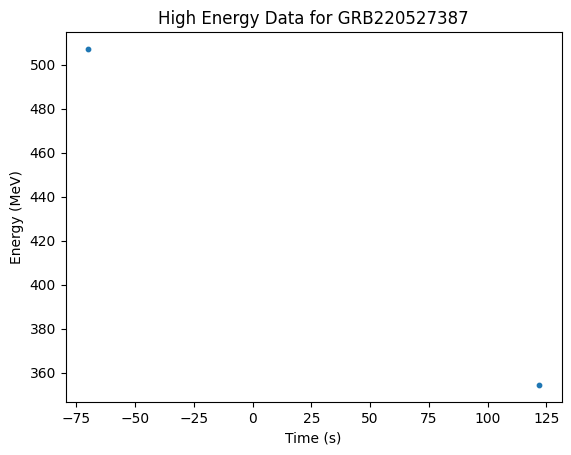

[[-70.01728403568268, 121.92130708694458], [507.07938, 354.4472]]


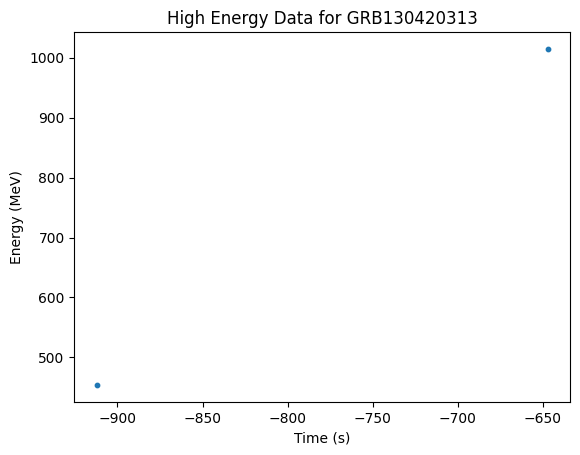

[[-647.1579678654671, -912.0134814381599], [1014.7452, 453.968]]
[0, 0]


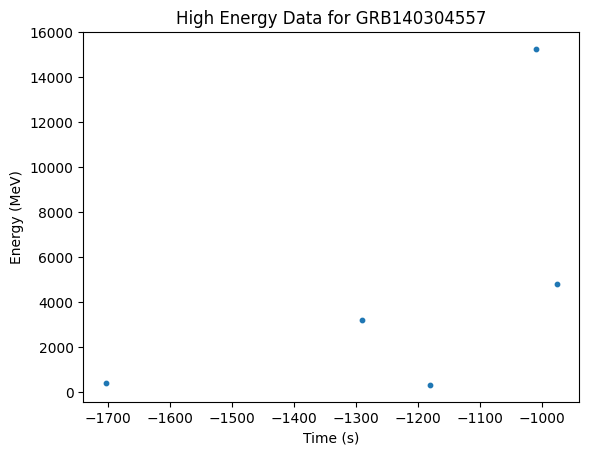

[[-1009.2597063779831], [15259.862]]


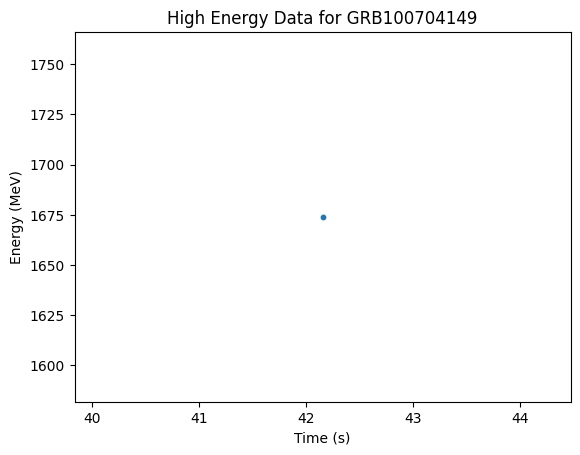

[[42.15076130628586], [1673.9581]]


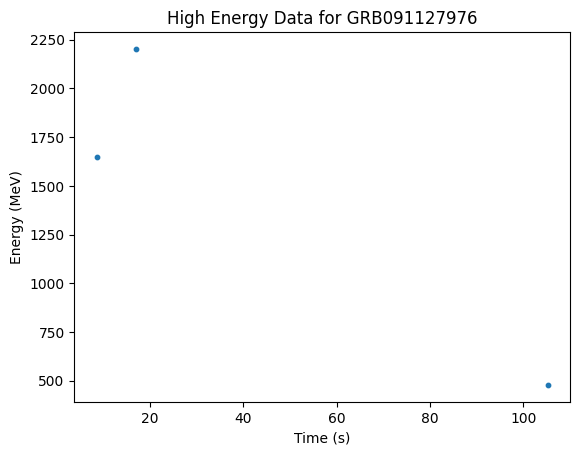

[[16.947929322719574, 8.619848728179932], [2203.0103, 1646.1329]]


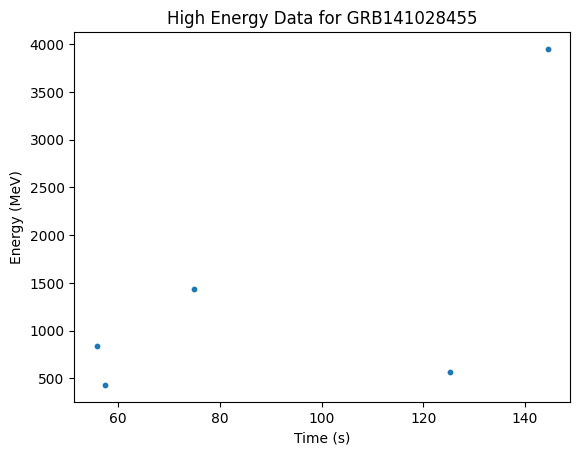

[[144.520425260067, 74.8747324347496], [3949.7961, 1431.3438]]
[0, 0]
[0, 0]


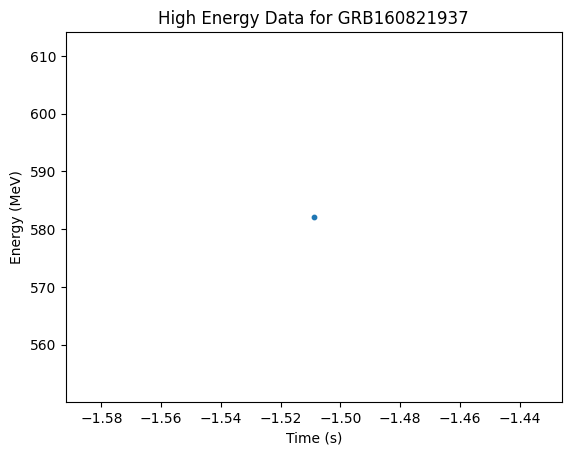

[[-1.508938491344452], [582.11176]]
[0, 0]


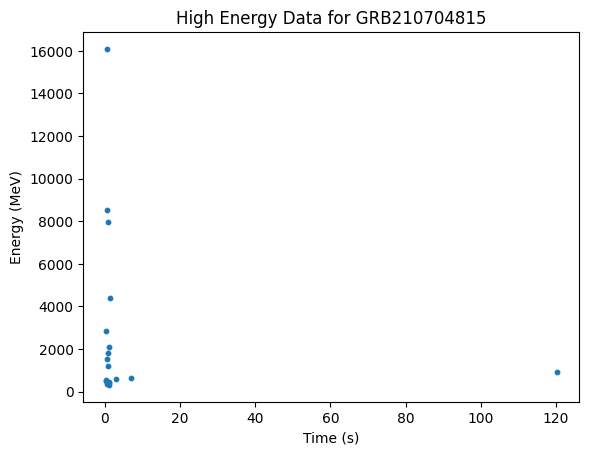

[[0.45928680896759033, 0.4798344373703003, 0.7135746479034424], [16089.984, 8542.303, 7945.4077]]


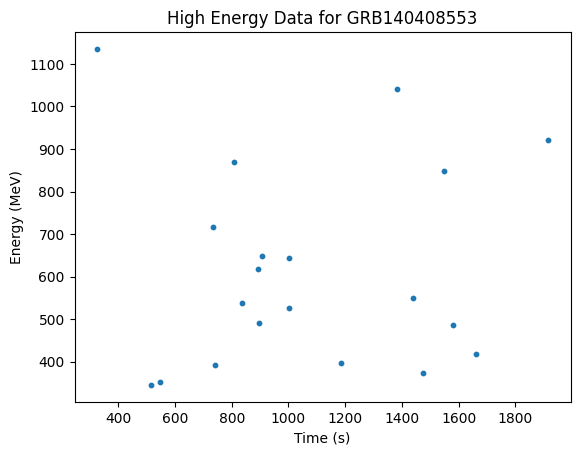

[[325.1384947299957, 1383.0622589588165, 1914.9659843444824, 807.5324169397354, 1548.3971677422523, 735.1885249018669, 906.779078245163, 1001.1559264063835, 892.8689460158348, 1437.8561303019524, 834.8738340735435, 1002.9961242079735, 897.4601115584373, 1578.3560032248497, 1659.8516350984573], [1135.0394, 1041.2881, 920.6088, 868.2566, 847.2185, 717.4337, 649.62775, 643.1463, 618.1903, 550.2896, 537.2493, 526.32367, 491.78873, 485.7834, 417.52917]]


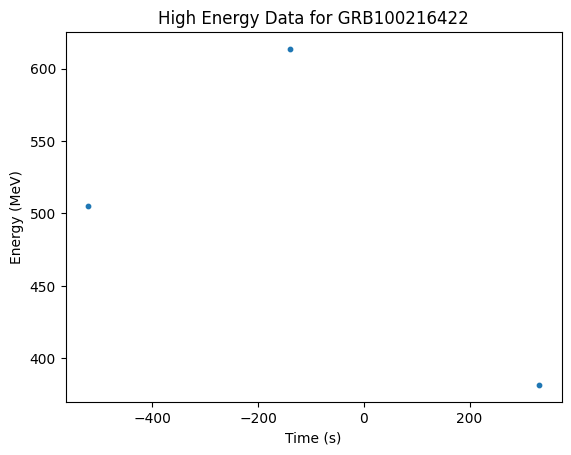

[[-139.86076533794403, -521.2170880436897, 331.5802620649338], [613.5554, 505.35495, 381.58774]]


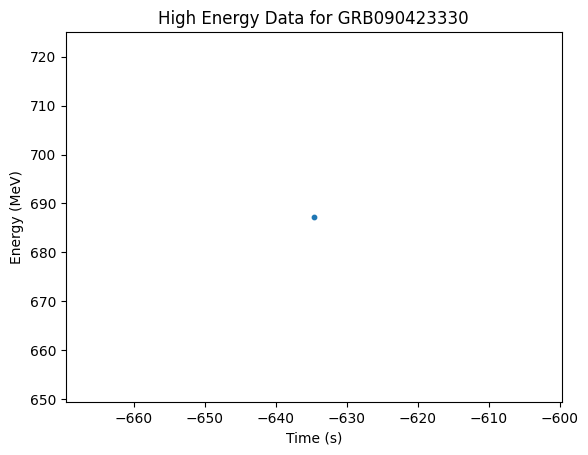

[[-634.6311985254288], [687.2441]]
[0, 0]
[0, 0]
[0, 0]


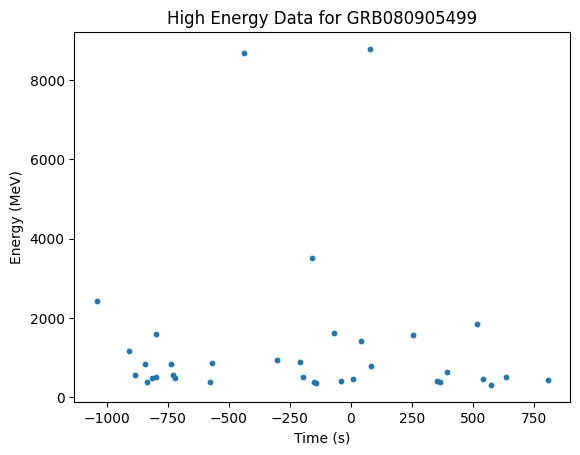

[[81.0066773891449, -436.5997498333454, -159.98835575580597], [8782.984, 8682.514, 3512.103]]


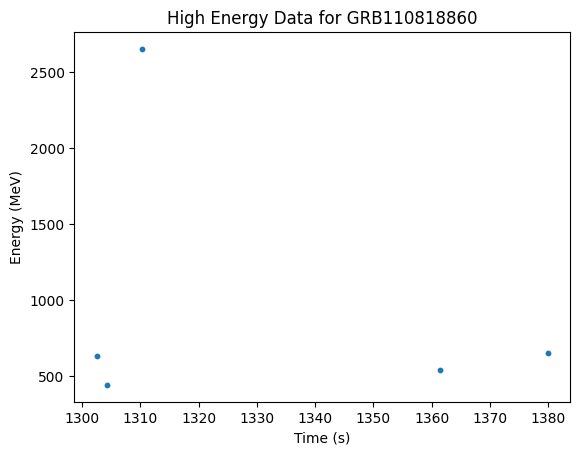

[[1310.2828691601753], [2653.354]]


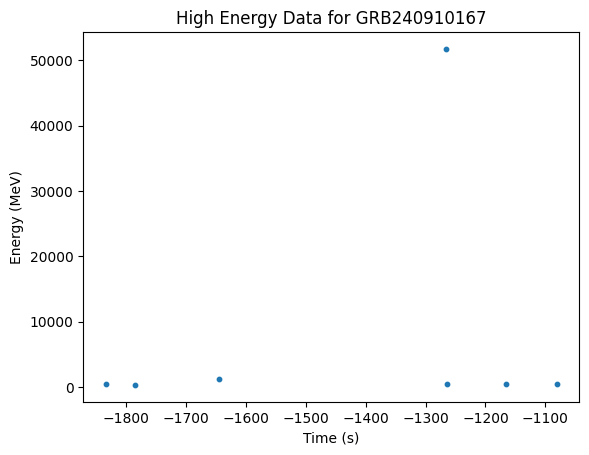

[[-1265.9703804254532], [51720.06]]
[0, 0]
[0, 0]


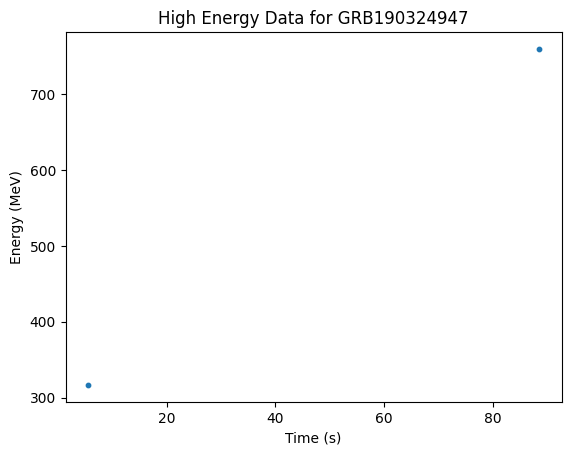

[[88.55070757865906, 5.561428785324097], [759.141, 316.8888]]
[0, 0]


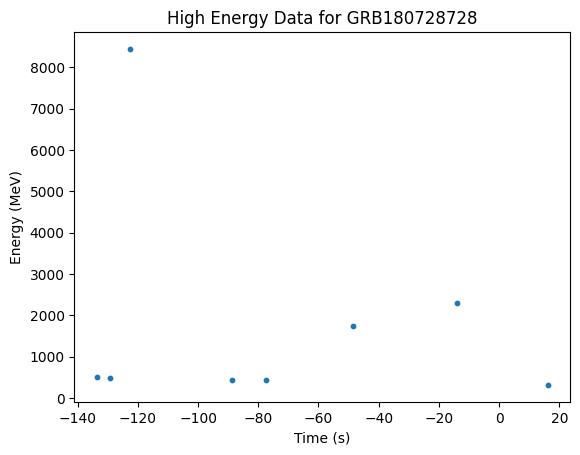

[[-122.73745787143707], [8448.857]]
[0, 0]


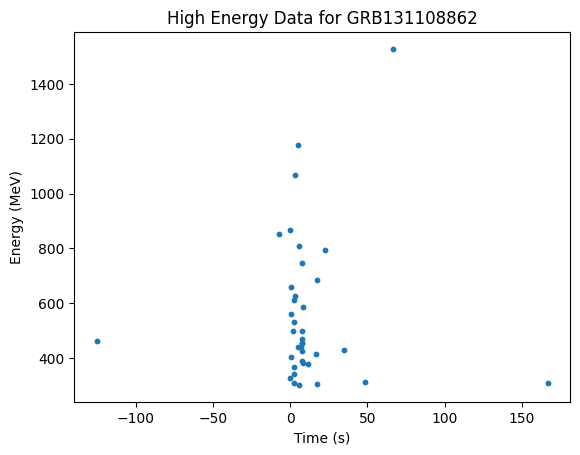

[[66.32652652263641, 5.214471697807312, 2.8413503766059875, 0.19474315643310547, -6.917639255523682, 5.9849963784217834, 22.728104770183563, 7.619985938072205, 17.53367042541504, 0.8811675310134888, 2.918318748474121, 2.6546735763549805, 8.147178411483765, 0.7758906483650208], [1527.6462, 1177.6459, 1068.7401, 868.51294, 852.35315, 807.97943, 795.4702, 748.0868, 685.3124, 660.41785, 628.11066, 613.29004, 587.1379, 559.25757]]


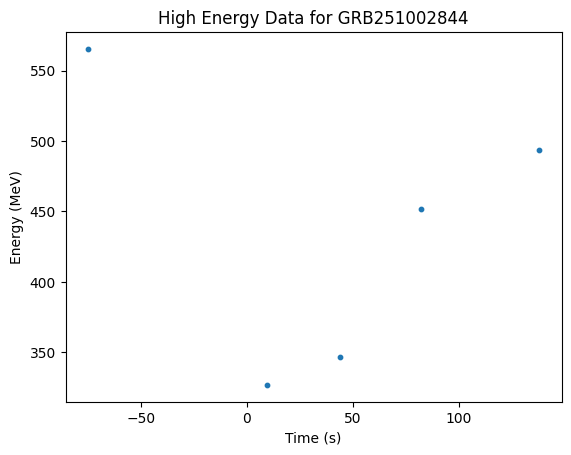

[[-75.10158395767212, 138.04040265083313, 82.07874274253845, 43.99983370304108, 9.394174456596375], [565.42505, 493.96918, 451.6261, 346.8574, 326.83356]]


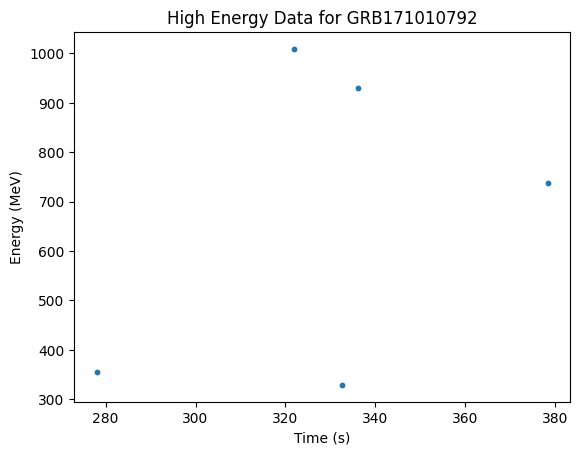

[[321.8882690668106, 336.17305040359497, 378.40113562345505, 278.0606191754341], [1009.1428, 930.6345, 737.87213, 355.18976]]


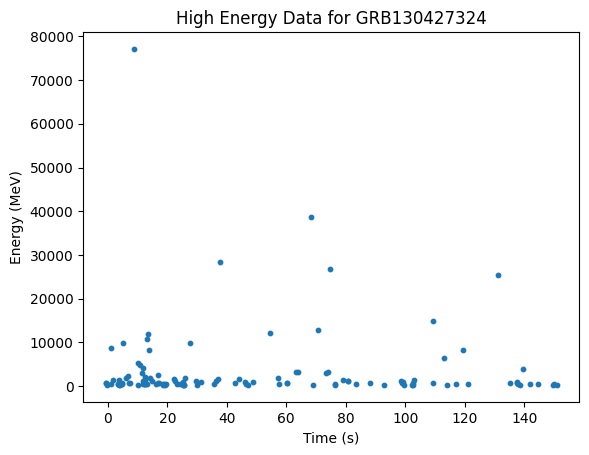

[[8.6441929936409, 68.39669126272202, 37.58764868974686], [77106.875, 38671.496, 28410.695]]


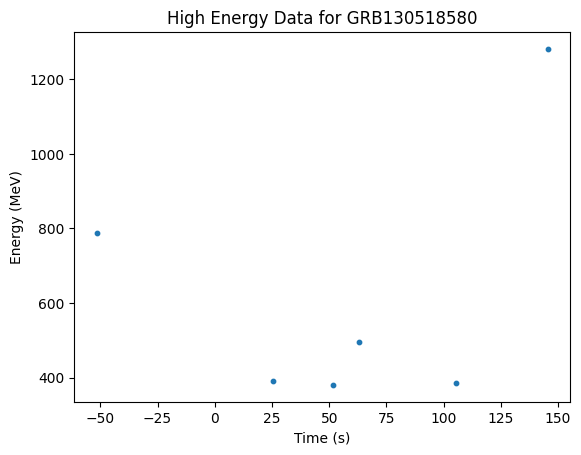

[[145.53297263383865, -51.487040579319, 63.18268221616745], [1281.0187, 787.39075, 496.94196]]


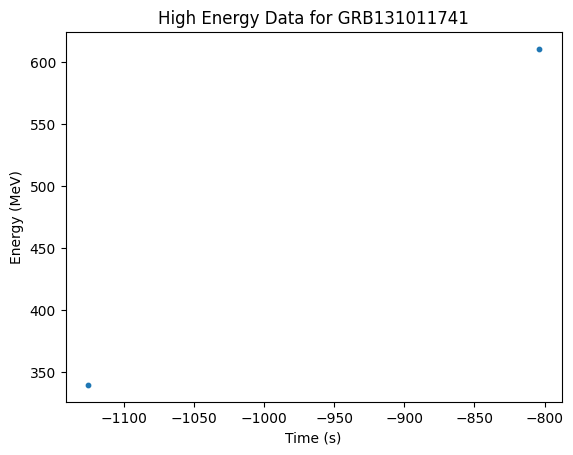

[[-803.8824949860573, -1125.5057502985], [610.76556, 339.40277]]


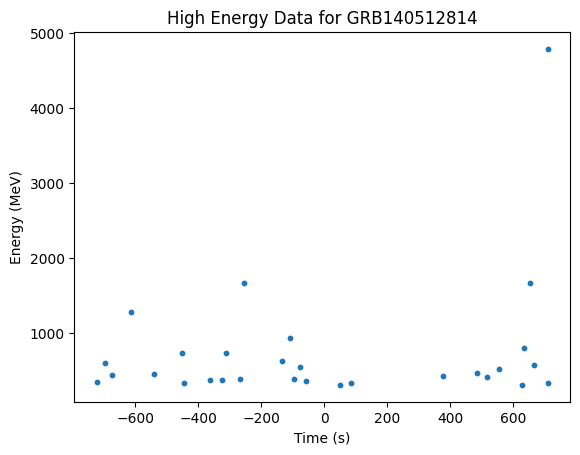

[[709.8476767539978], [4785.3413]]
[0, 0]


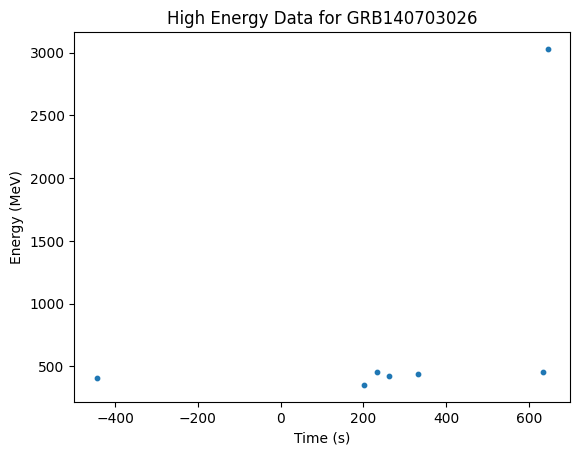

[[645.8347499966621], [3029.6863]]


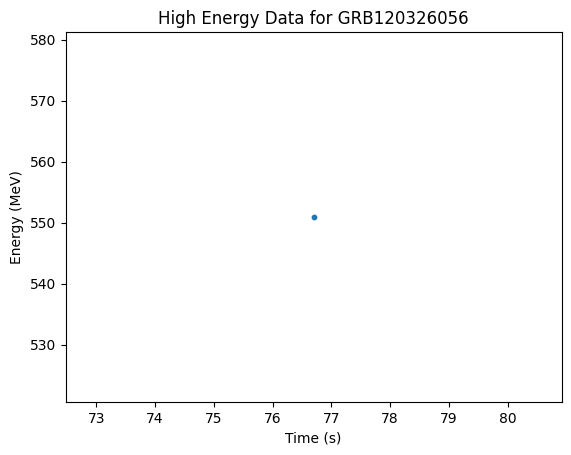

[[76.69989901781082], [550.9214]]
[0, 0]
[0, 0]


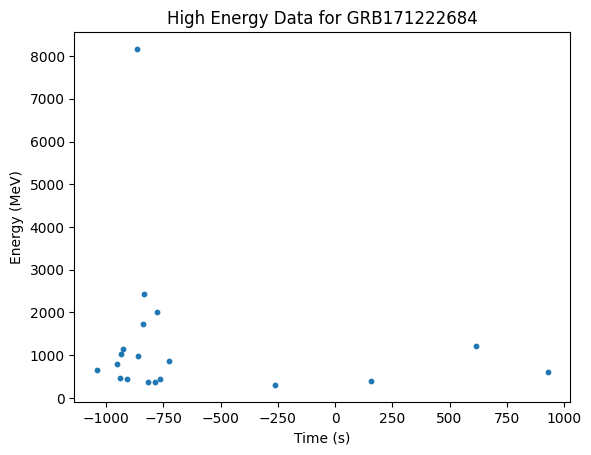

[[-863.7314699888229], [8166.95]]


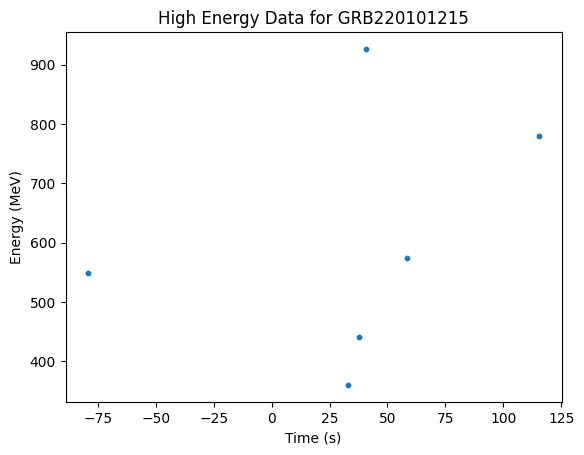

[[40.818302154541016, 115.48032259941101, 58.43327498435974, -79.17182457447052, 37.7341274023056, 33.01392185688019], [926.7335, 779.51575, 574.83307, 549.4948, 441.08148, 360.28366]]


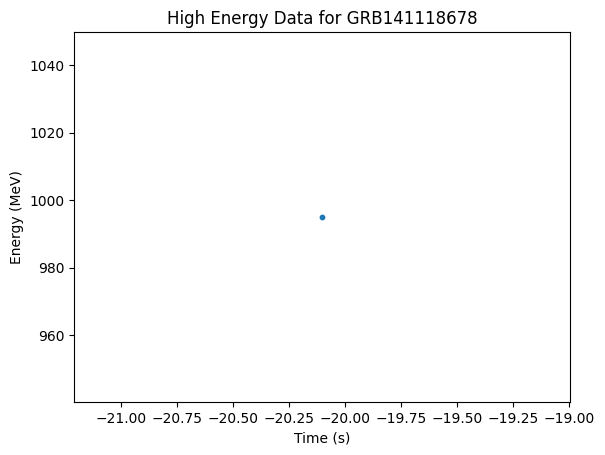

[[-20.10123646259308], [995.03217]]
[0, 0]


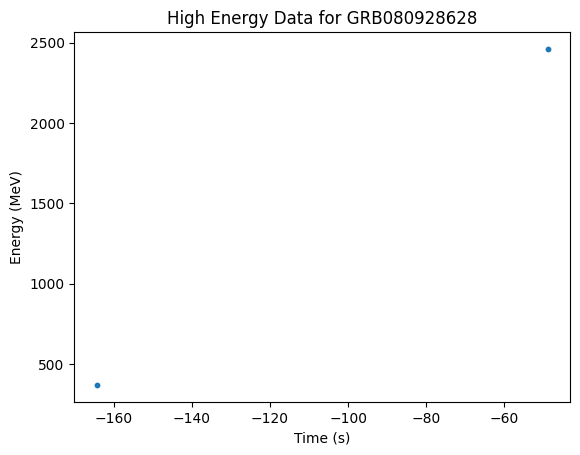

[[-48.80291432142258], [2460.7556]]
[0, 0]


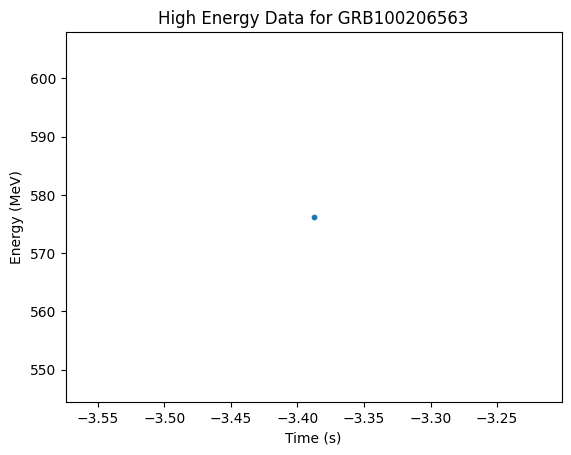

[[-3.3878268599510193], [576.2153]]


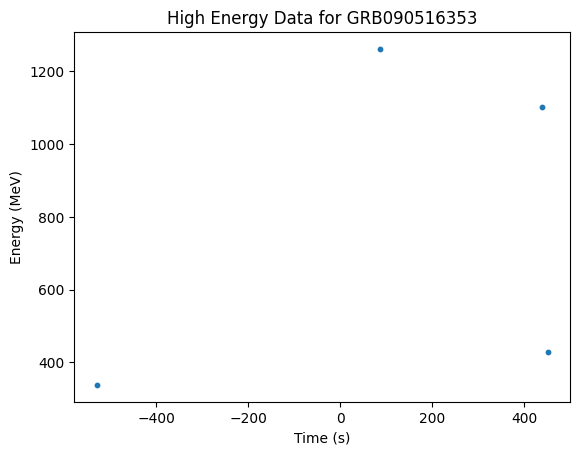

[[85.8673468530178, 439.018986672163], [1262.1139, 1103.1901]]
[0, 0]


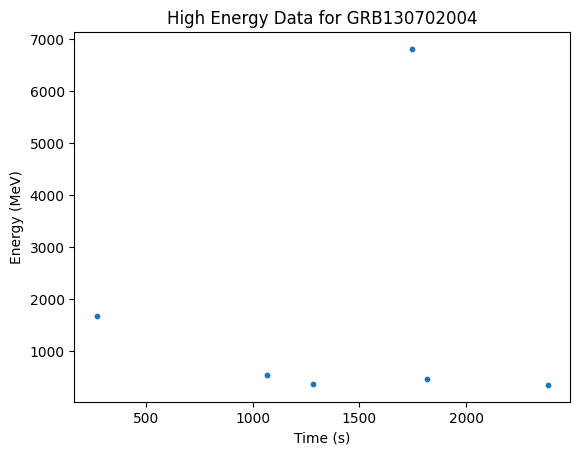

[[1744.5241954922676], [6815.287]]
[0, 0]
[0, 0]
[0, 0]


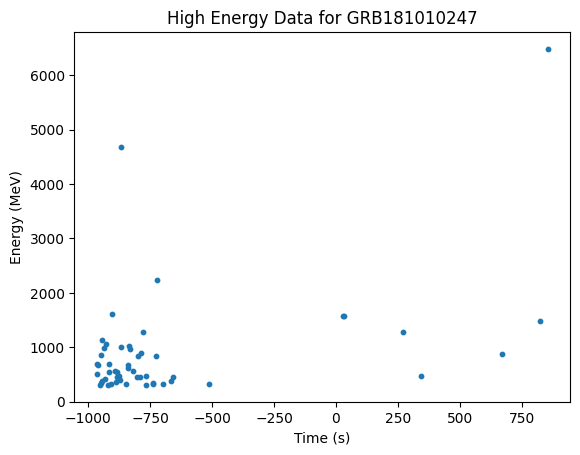

[[856.0132421255112, -866.179089307785], [6480.812, 4680.512]]


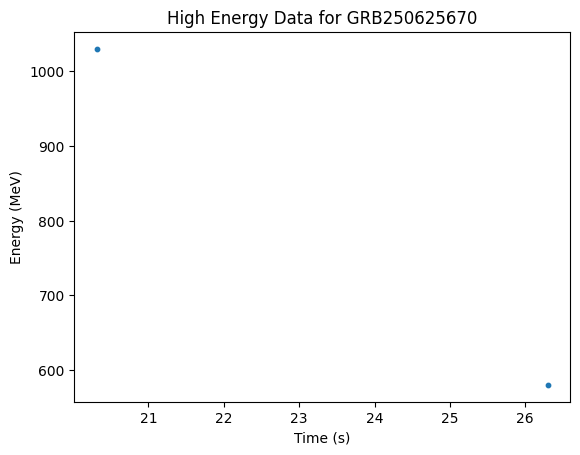

[[20.317983627319336, 26.299646735191345], [1030.1444, 580.2307]]


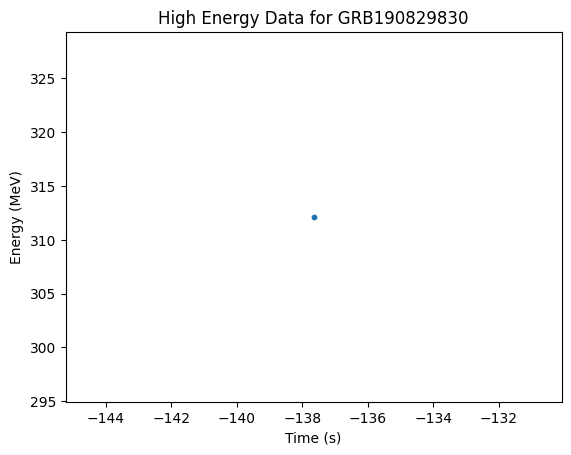

[[-137.65801906585693], [312.12802]]


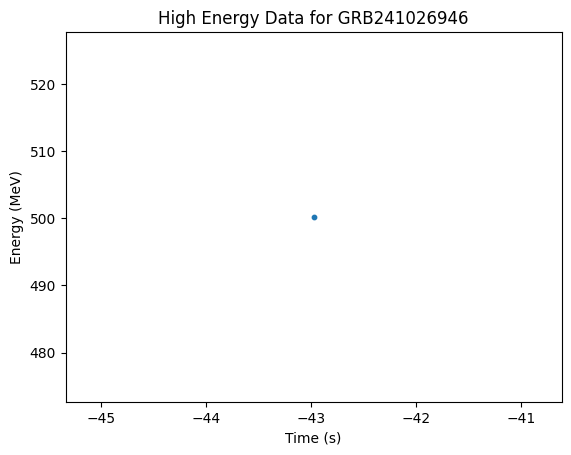

[[-42.976269602775574], [500.1909]]


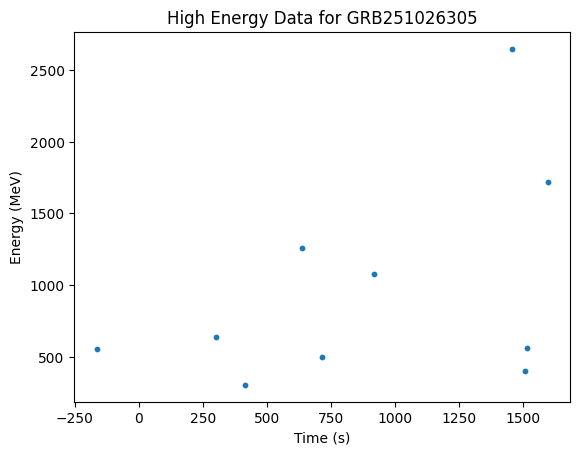

[[1455.7433533668518, 1597.0083248615265, 636.7164785861969, 919.8493446111679], [2648.043, 1716.9236, 1262.2333, 1079.2737]]
[0, 0]
[0, 0]
[0, 0]


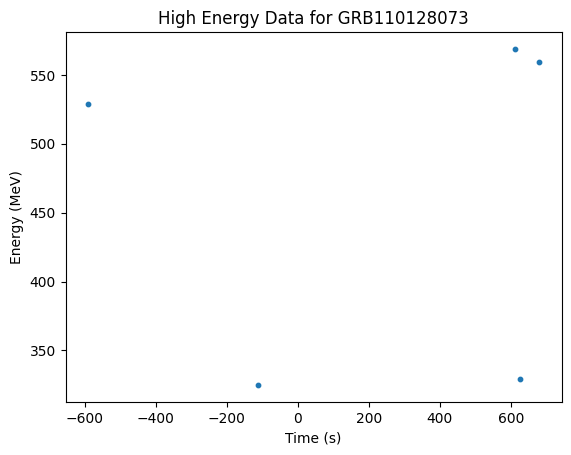

[[612.9333175420761, 679.4891236424446, -590.017031788826, 624.8521139621735, -110.64187502861023], [568.80725, 559.1085, 528.9313, 329.22537, 324.97647]]
[0, 0]


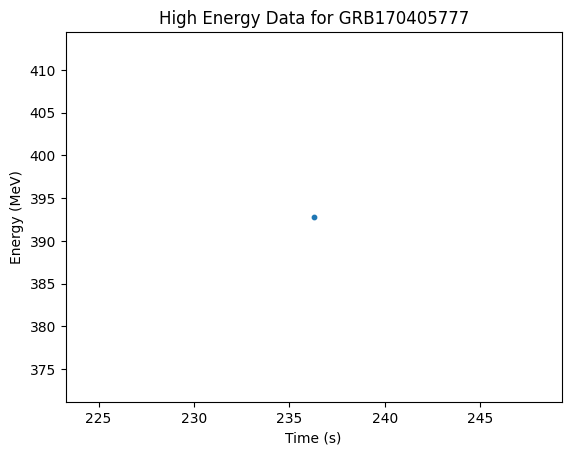

[[236.26864725351334], [392.8087]]
[0, 0]
[0, 0]


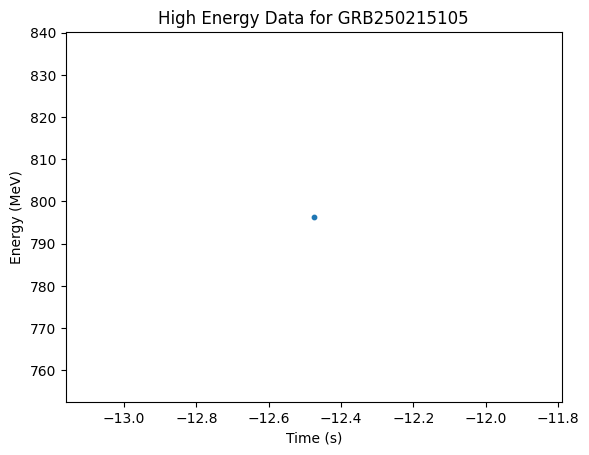

[[-12.475152730941772], [796.33887]]
[0, 0]


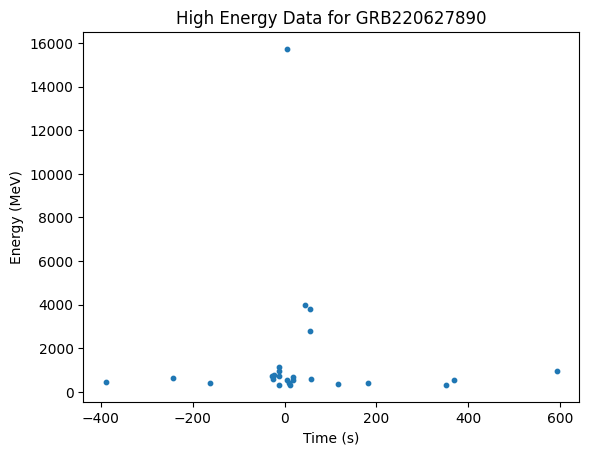

[[4.477855563163757], [15729.1]]
[0, 0]


In [29]:
big_list = {}
for i in range(len(list(data.items()))):
    event = list(data.items())[i][0]
    result = getLATPLOT_II(event, 10)
    big_list[event] = result
    print(result)

In [ ]:
data["190114873"]["lat_highs"]
x = [float(i["Max Time"]) - data["190114873"]["low_t"] for i in data["190114873"]["lat_highs"]]
y = [float(i["Max Energy"]) for i in data["190114873"]["lat_highs"]]

plt.scatter(x,y,s=10)
#plt.xlim(-1200, 1200)
plt.title("High Energy Data for GRB190114873")
plt.xlabel("Time (s)")
plt.ylabel("Energy (MeV)")

In [473]:
data["221009553"]['half_max_t']

64.5

Text(0, 0.5, 'Energy (MeV)')

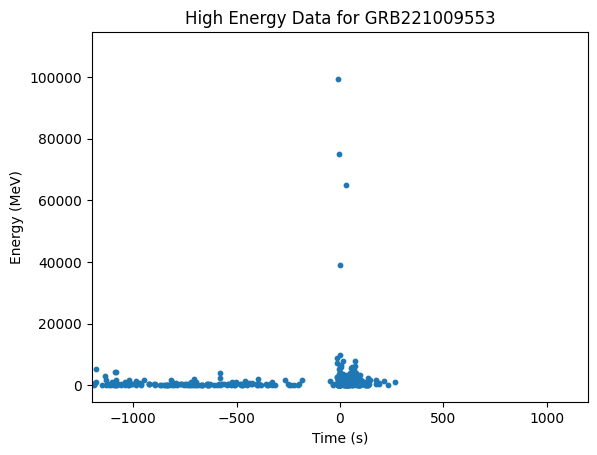

In [474]:
data["221009553"]["lat_highs"]
x = [float(i["Max Time"]) - data["221009553"]["low_t"] for i in data["221009553"]["lat_highs"]]
y = [float(i["Max Energy"]) for i in data["221009553"]["lat_highs"]]

plt.scatter(x,y,s=10)
plt.xlim(-1200, 1200)
plt.title("High Energy Data for GRB221009553")
plt.xlabel("Time (s)")
plt.ylabel("Energy (MeV)")

In [37]:
with open('data/lat_error_plot.json', 'r') as file:
    lat_err = json.load(file)

In [476]:
#lat_err

In [30]:
def get_lat_err(E):
    for i in range(len(lat_err)):
        if E < float(lat_err[i]['x']):
            diff = float(lat_err[i]['y']) - float(lat_err[i-1]['y'])
            scale = (E-float(lat_err[i-1]['x']))/(float(lat_err[i]['x'])-float(lat_err[i-1]['x']))
            #print(diff)
            #print(scale)
            err = diff*scale + float(lat_err[i-1]['y'])
            return err

In [31]:
def eIG(t):
    num = np.float128((1+t))
    den = np.float128((Lambda_m*(1+t)**3)+Lambda_G)
    return num/((np.sqrt(den))**3)

In [32]:
def eIm(t):
    num = np.float128((1+t)**4)
    den = np.float128((Lambda_m*(1+t)**3)+Lambda_G)
    return num/((np.sqrt(den))**3)

In [33]:
def eK(K, E, z):
    error = -1
    H_e = (H_err/H_naught_mpc)**2
    E_e = (get_lat_err(E)/E)**2
    Ig_e = (sp.integrate.quad(eIG, 0, z)[0])**2
    Im_e = (sp.integrate.quad(eIm, 0, z)[0])**2
    error = K*np.sqrt(H_e+E_e+G_err*Ig_e+m_err*Im_e)
    return error

In [34]:
found = 0
time = 4 #1
t_list = []
e_list = []
z_list = []
s_list = []
w_list = []
t_err_list = []
error_list = [] #[et, eK]
for n in data:
    #print("Checking " + n)
    fail = True
    if data[n]["half_max_t"] > 10*(1+float(data[n]["redshift"])): #1
        continue
    if data[n]["significance"] < 5: #12
        continue
    #s_list = (data[n]["significance"]**8)/50000
    if big_list[n] != [0,0]:
        for l in range(len(big_list[n][0])):
            t_list.append((big_list[n][0][l])/(1+float(data[n]["redshift"])))
            t_err_list.append(np.sqrt((data[n]["half_max_t"])**2)+((0.0001)**2))
            e_list.append(big_list[n][1][l])
            z_list.append(float(data[n]["redshift"]))
            w_list.append(data[n]["half_max_t"]/data[n]["significance"])
            #print("GRB " + str(n) + " has energy " + str(max_E) + " at time " + str((big_cluster_set[n][i][0])/(1+float(data[n]["redshift"]))))

print(len(e_list))

137


In [499]:
#found = 0
#time = 4 #1
#t_list = []
#e_list = []
#z_list = []
#s_list = []
#w_list = []
#t_err_list = []
#error_list = [] #[et, eK]
#for n in data:
#    #print("Checking " + n)
#    fail = True
#    if data[n]["half_max_t"] > 10*(1+float(data[n]["redshift"])): #1
#        continue
#    if data[n]["significance"] < 5: #12
#        continue
#    #s_list = (data[n]["significance"]**8)/50000
#    for i in range(len(big_list[n])):
#        if big_list[n][i] != 0:
#            if float(big_list[n][i][1]) > 3:
#                max_time = (300*time)
#                #print("Checking... " + str(n))
#                if abs(big_cluster_set[n][i][0])/(1+float(data[n]["redshift"])) < max_time:
#                    fail = False
#                    found = found + 1
#                    t_list.append((big_cluster_set[n][i][0])/(1+float(data[n]["redshift"])))
#                    t_err_list.append(np.sqrt((data[n]["half_max_t"])**2)+((0.0001)**2))
#                    max_E = 0
#                    for j in big_cluster_set[n][i][3]:
#                        if j != 0:
#                            max_E = j
#                    e_list.append(max_E)
#                    z_list.append(float(data[n]["redshift"]))
#                    w_list.append(data[n]["half_max_t"]/data[n]["significance"])
#                    print("GRB " + str(n) + " has energy " + str(max_E) + " at time " + str((big_cluster_set[n][i][0])/(1+float(data[n]["redshift"]))))
                        

        #print("Failure")
#print("Good Samples: " + str(found))
#print(e_list)
#Samples under 5 mins (88/122)
#Samples under 10 mins (111/173)
#Samples under 15 mins (131/199)
#Samples under 20 mins (157/212)
#Samples under 25 mins (179/224)
#Samples under 30 mins (194/230)
#Samples under 60 mins (232/232)
#Samples under 120 mins (233/233)

In [35]:
E = 300
z = 8.2
t = t_list[2]
K_int = sp.integrate.quad(f, 0, z)[0]
K = float(1/(H_naught))*float((E)/(1+z))*float(K_int)
(K/(3*10**15))

33704.68185801827

In [38]:
k_list = []
k_err_list = []
for i in range(len(e_list)):
    E = e_list[i]
    z = z_list[i]
    t = t_list[i]
    K_int = sp.integrate.quad(f, 0, z)[0]
    K = float(1/(H_naught))*float((E)/(1+z))*float(K_int)
    k_err_list.append(eK(K, E, z))
    k_list.append(K)

print(len(k_list))

137


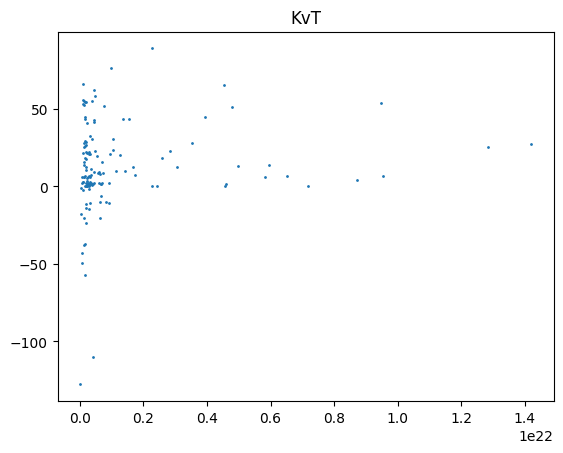

In [39]:
plt.title("KvT")
plt.scatter(k_list,t_list,s=1)
#plt.errorbar(k_list,t_list, yerr=t_err_list, xerr=k_err_list, fmt="o")
plt.show()

In [40]:
test = 0
tot = 0
for i in range(len(t_list)):
    tot = tot + k_list[i]
    if t_list[i] > 0:
        test = test + k_list[i]
print(str(test/tot))

0.9627297551133497


In [41]:
test = 0
tot = 0
for i in range(len(t_list)):
    tot = tot + 1
    if t_list[i] > 0:
        test = test + 1
print(str(test/tot))

0.8394160583941606


In [505]:
len(t_list)

477

In [56]:
k_over = []
k_over_e = []
t_over = []
t_over_e = []
z_over = []
for i in range(len(t_list)):
    if t_list[i] > 0:
        k_over.append(k_list[i])
        t_over.append(t_list[i])
        k_over_e.append(k_err_list[i])
        t_over_e.append(t_err_list[i])
        z_over.append(z_list[i])

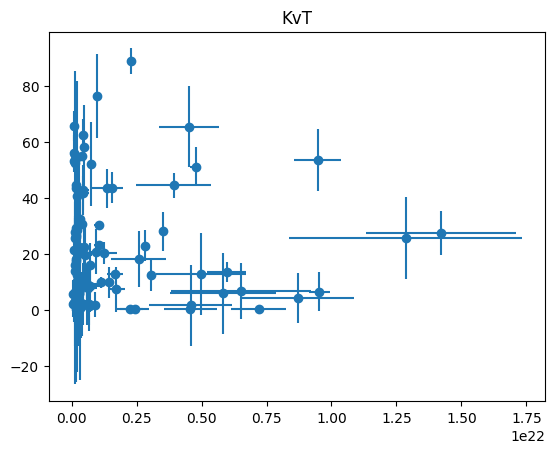

In [57]:
plt.title("KvT")
plt.scatter(k_over,t_over,s=0.1)
plt.errorbar(k_over,t_over, xerr=k_over_e, yerr=t_over_e, fmt="o")
plt.show()

In [434]:
def fit_func(x, beta):
    # Curve fitting function
    a = beta[0]
    return a * x  # d=0 is implied

In [435]:
def curve_fit_func(x, a):
    # Curve fitting function
    return a * x  # d=0 is implied

In [436]:
X = k_over
Y = t_over

# Calculate weights based on the inverse of the variance of the errors
errors_times = []
for i in range(len(t_over)):
    tot = (t_over[i])/k_over[i]
    t_e = (t_over_e[i]/(t_over[i]*(1+z_over[i])))**2
    k_e = (k_over_e[i]/k_over[i])**2
    tot_e = tot*np.sqrt(t_e+k_e)
    #errors_times.append(1/tot_e**2)
    errors_times.append(1/tot_e**0.2)
    #errors.append(0.1)

errors_plus = []
for i in range(len(t_over)):
    tot = t_over[i]+k_over[i]
    t_e = (t_over_e[i])**2
    k_e = (k_over_e[i])**2
    tot_e = np.sqrt(t_e+k_e)
    errors_plus.append(1/tot_e**2)
    #errors.append(0.1)


params = curve_fit(curve_fit_func, X, Y)
fit_zero = params[0]
print("===========| " + str(fit_zero[0]) + " |===========")

weight_x = k_over_e
weight_y = t_over_e
beta0 = [1.45002541*10**(-19)]

fit_odr = odr_fit(fit_func, X, Y, beta0, weight_x=weight_x, weight_y=weight_y)
print("===========| " + str(fit_odr.beta[0]) + " |===========")
fit_odr = fit_odr.beta[0]

fit = np.polyfit(X, Y, 1, w=errors_times,full=True)
# Fit weighted least squares regression model
#X = sm.add_constant(X)
#model = sm.WLS(y, X, weights=weights)
#results = model.fit()
#results.summary()
fit

===========| 9.948921857843772e-20 |===========
===========| 1.0195476674467139e-19 |===========


(array([ 7.21542994e-20, -6.66876995e+01]),
 array([5.34981265e+15]),
 np.int32(2),
 array([1.29125243, 0.57677306]),
 np.float64(3.752553823233029e-14))

In [437]:
#fit-vals [x, c]
#residuals – sum of squared residuals of the least squares fit
#rank – the effective rank of the scaled Vandermonde coefficient matrix
#singular_values – singular values of the scaled Vandermonde coefficient matrix
#rcond

In [438]:
tss = 0
for i in range(len(k_over)):
    tss = tss + (t_over[i]-(fit[0][1] - fit[0][0]*k_over[i]))**2
tss

np.float64(479985651.4026652)

In [439]:
r_squared = 1 - fit[1][0]/tss
r_squared

np.float64(-11145775.198580585)

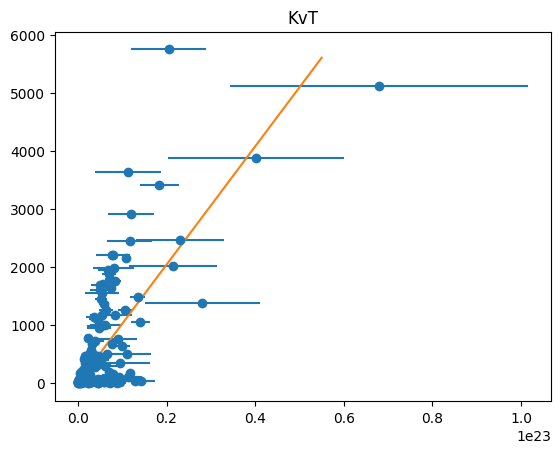

In [459]:
plt.title("KvT")
plt.scatter(k_over,t_over,s=0.1)
plt.errorbar(k_over,t_over, xerr=k_over_e, yerr=t_over_e, fmt="o")
plot_k = []
plot_t = []
k_top = 0.55*(10**23)
plot_t.append(fit_odr*k_top)
plot_k.append(k_top)
for val_k in k_over:
    #plot_t.append(fit[0][1] - fit[0][0]*val_k)
    if fit_odr*val_k < 6910:
        plot_t.append(fit_odr*val_k)
        plot_k.append(val_k)
plt.plot(plot_k,plot_t)
plt.show()

In [460]:
E_qg = 1/fit[0][0]
E_qg

np.float64(1.385918799606651e+19)

In [461]:
E_qg = 1/fit_odr
E_qg

np.float64(9.808271176808557e+18)

In [462]:
E_qg = 1/fit[0][0]
E_qg

np.float64(1.385918799606651e+19)

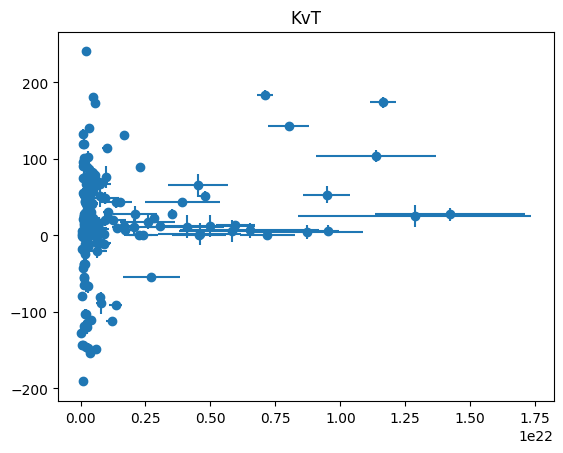

In [403]:
plt.title("KvT")
plt.scatter(k_list,t_list,s=0.1)
plt.errorbar(k_list,t_list, xerr=k_err_list, yerr=t_err_list, fmt="o")
plt.show()

In [401]:
X = k_list
Y = t_list

# Calculate weights based on the inverse of the variance of the errors
errors_times = []
for i in range(len(t_list)):
    tot = (t_list[i])/k_list[i]
    t_e = (t_err_list[i]/(t_list[i]*(1+z_list[i])))**2
    k_e = (k_err_list[i]/k_list[i])**2
    tot_e = tot*np.sqrt(t_e+k_e)
    #errors_times.append(1/tot_e**2)
    errors_times.append(1/tot_e**0.2)
    #errors.append(0.1)

errors_plus = []
for i in range(len(t_list)):
    tot = t_list[i]+k_list[i]
    t_e = (t_err_list[i])**2
    k_e = (k_err_list[i])**2
    tot_e = np.sqrt(t_e+k_e)
    errors_plus.append(1/tot_e**2)
    #errors.append(0.1)


params = curve_fit(curve_fit_func, X, Y)
fit_zero = params[0]
print("===========| " + str(fit_zero[0]) + " |===========")

weight_x = k_err_list
weight_y = t_err_list
beta0 = [1.45002541*10**(-19)]

fit_odr = odr_fit(fit_func, X, Y, beta0, weight_x=weight_x, weight_y=weight_y)
print("===========| " + str(fit_odr.beta[0]) + " |===========")
fit_odr = fit_odr.beta[0]

#fit = np.polyfit(X, Y, 1, w=errors_times,full=True)
# Fit weighted least squares regression model
#X = sm.add_constant(X)
#model = sm.WLS(y, X, weights=weights)
#results = model.fit()
#results.summary()
#fit

===========| 6.6274820841989384e-21 |===========
===========| 5.822438065537031e-21 |===========


/tmp/ipykernel_400640/3335383811.py:12: RuntimeWarning: invalid value encountered in scalar power
  errors_times.append(1/tot_e**0.2)


In [59]:
Big_table = pandas.read_sql_query("SELECT * from Summary", db)
Big_table = Big_table.sort_values("redshift", ascending=False)
Second = Big_table[:740].sort_values("GRB_name_Fermi", ascending=False)
final = Second[:275]

names = final["GRB_name_Fermi"]
big_list = []
for i in names:
    #print(i)
    big_list.append(i.split("B")[1])

In [61]:
data["140619"]

KeyError: '140619'

In [60]:
for i in big_list:
    if i in data:
        x = 0
    else:
        print(i)

260208214
260131277
260114486
260101039
251222712
251214377
251201685
230812790
200411187
200219317
180805543
180727594
180618030
180418281
170903534
170817529
170728961
170127634
160411062
160408268
151229285
140713780
131229277
130907904
130716442
130515056
121123421
110402009
101224227
081008832
080916009
080810549
080804972


In [72]:
hdul_image = fits.open("data/MAGIC_2014_3C58.fits")
hdul_data = hdul_image[2].data

In [73]:
hdul_data

array([[ 0.18039219,  0.1985301 ,  0.21156225, ...,  0.29416585,
         0.3924955 ,  0.47018585],
       [ 0.14461054,  0.15128759,  0.1528135 , ...,  0.23248099,
         0.33209276,  0.4114416 ],
       [ 0.09908409,  0.09404436,  0.08401501, ...,  0.13814536,
         0.23726672,  0.31730878],
       ...,
       [ 0.31670034,  0.4074839 ,  0.5248279 , ..., -0.2077888 ,
        -0.20580252, -0.1938345 ],
       [ 0.3828633 ,  0.46516505,  0.57086104, ..., -0.33708408,
        -0.3325903 , -0.31568912],
       [ 0.43861106,  0.51266754,  0.6069146 , ..., -0.43978298,
        -0.43330207, -0.41240433]], shape=(219, 306), dtype='>f4')